10/16
---

In [ ]:
### Data

In [1]:
import json
import argparse
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer, IntervalStrategy, AutoModelForCausalLM, AutoTokenizer
import random
import torch
import numpy as np
import sys
from graph_mistral import GraphMistralForCausalLM
sys.path.append("../")
from utils import prepare_training_ids, init_random_state


BOS = '<s>[INST]'
EOS_USER = '[/INST]'
EOS = '</s>'
IGNORE_INDEX = -100


LLM_INFER_PROMPT = """Please understand the user's request and generate task steps and task invocation graph to solve the request.\n""" \
                  + """## Requirements:\n1. The format must in a strict JSON format, like: {"task_steps": [ "concrete steps, format as Step x: Call xxx to do xxx" ], "task_nodes": [{"task": "task name must be from TASK LIST", "arguments": [ {"name": "parameter name", "value": "parameter value"} ]}], "task_links": [{"source": "task name i", "target": "task name j"}]}\n""" \
                  + """2. The generated task steps and task nodes can resolve the given user request perfectly. Task name must be selected from TASK LIST.\n""" \
                  + """3. The task steps should strictly aligned with the task nodes, and the number of task steps should be same with the task nodes.\n""" \
                  + """4. The task links (task_links) should reflect the dependencies among task nodes, i.e. the order in which the APIs are invoked, you should also understand each tool's input and output demands.\n""" \
                  + """## User Request:\n{{user_request}}\nNow please generate your response in a strict JSON format:\n## Response:\n"""



class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {}
        for key, val in self.encodings.items():
            if isinstance(val, torch.Tensor):
                item[key] = val[idx]
            else:
                item[key] = torch.tensor(val[idx])
        item['idx'] = idx
        if self.labels:
            item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.encodings["input_ids"])


class GraphTrainer(Trainer):
    """Custom Trainer that passes graph-specific inputs to the model"""

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Override compute_loss to pass token_type_ids and graph_attention_mask to the model
        """
        # Extract graph-specific inputs
        token_type_ids = inputs.pop("token_type_ids", None)
        graph_attention_mask = inputs.pop("graph_attention_mask", None)

        # Forward pass with graph inputs
        if token_type_ids is not None:
            inputs["token_type_ids"] = token_type_ids
        if graph_attention_mask is not None:
            inputs["graph_attention_mask"] = graph_attention_mask

        # Get model outputs
        outputs = model(**inputs)

        # Extract logits and labels
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs.logits
        labels = inputs.get("labels")

        # Compute loss
        if labels is not None:
            # Shift tokens for causal LM: predict next token
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()

            # Flatten the tokens
            loss_fct = torch.nn.CrossEntropyLoss()
            shift_logits = shift_logits.view(-1, shift_logits.size(-1))
            shift_labels = shift_labels.view(-1)

            # Enable model parallelism
            shift_labels = shift_labels.to(shift_logits.device)
            loss = loss_fct(shift_logits, shift_labels)
        else:
            loss = None

        return (loss, outputs) if return_outputs else loss


def prepare_llm_training_data(dataset_name="huggingface", train_ids=None):
    """
    Prepare training data samples (without graph processing).
    Graph structure is handled separately for efficiency.
    """
    raw_data = f"../data/{dataset_name}/data.json"
    data_contents = []

    for line in open(raw_data, 'r'):
        content = json.loads(line)

        if train_ids and content["id"] not in train_ids:
            continue

        input = content['user_request']
        prompt = LLM_INFER_PROMPT

        output = {
                "task_steps": content["task_steps"],
                "task_nodes": content["task_nodes"],
                "task_links": content["task_links"]
        }

        data_contents.append({
            'id': content['id'],
            'prompt': prompt,
            "input": input,
            "output": json.dumps(output),
        })

    random.shuffle(data_contents)
    return data_contents


def prepare_graph_structure(dataset_name):
    """
    Prepare graph structure once for the entire dataset.
    Tokenizes the graph and builds the base attention mask that will be reused.

    Args:
        dataset_name: name of the dataset

    Returns:
        dict with:
            - graph_str: the formatted graph string
            - graph_token_ids: tokenized graph
            - graph_token_spans: dict mapping tool_name -> (start_idx, end_idx) relative to graph
            - base_graph_mask: [graph_len, graph_len] attention mask for graph region
    """
    tool_file = f"../data/{dataset_name}/tool_desc.json"
    tool_desc_data = json.load(open(tool_file, 'r'))
    all_tools = [tool['id'] for tool in tool_desc_data['nodes']]

    # Load graph edges
    try:
        graph_file = f"../data/{dataset_name}/graph_desc.json"
        graph_links = json.load(open(graph_file, 'r'))['links']
    except:
        # If no graph_desc.json, create empty links (no edges)
        graph_links = []

    # Create graph representation
    graph_str = "<start_graph>" + "".join([f"<node>{tool}" for tool in all_tools]) + "<end_graph>"

    # Tokenize the graph once
    graph_token_ids = tokenizer(graph_str, add_special_tokens=False).input_ids

    # Find token spans for each tool (relative positions within graph)
    graph_token_spans = {}
    for tool_name in all_tools:
        tool_marker = f"<node>{tool_name}"
        tool_tokens = tokenizer(tool_marker, add_special_tokens=False).input_ids

        # Find where this tool appears in graph_token_ids
        for i in range(len(graph_token_ids) - len(tool_tokens) + 1):
            if graph_token_ids[i:i+len(tool_tokens)] == tool_tokens:
                graph_token_spans[tool_name] = (i, i + len(tool_tokens))
                break

    # Build base graph attention mask (only for graph region)
    graph_len = len(graph_token_ids)
    base_graph_mask = torch.zeros(graph_len, graph_len, dtype=torch.bool)

    # Allow full self-attention within each node
    for tool_name, (start_idx, end_idx) in graph_token_spans.items():
        base_graph_mask[start_idx:end_idx, start_idx:end_idx] = True

    # Add edges from graph_links
    for link in graph_links:
        source_tool = link["source"]
        target_tool = link["target"]

        if source_tool in graph_token_spans and target_tool in graph_token_spans:
            source_start, source_end = graph_token_spans[source_tool]
            target_start, target_end = graph_token_spans[target_tool]

            # Bidirectional blocked attention
            base_graph_mask[source_start:source_end, target_start:target_end] = True
            base_graph_mask[target_start:target_end, source_start:source_end] = True

    return {
        'graph_str': graph_str,
        'graph_token_ids': graph_token_ids,
        'graph_token_spans': graph_token_spans,
        'base_graph_mask': base_graph_mask,
        'all_tools': all_tools
    }


def tokenizer_dataset(raw_data, graph_info):
    """
    Tokenize dataset using pre-built graph structure (EFFICIENT VERSION).

    Args:
        raw_data: list of data samples
        graph_info: dict from prepare_graph_structure() containing pre-built graph

    Returns:
        dict with input_ids, attention_mask, labels, token_type_ids, graph_attention_mask
    """
    bos_tokens = tokenizer(BOS, add_special_tokens=False)
    eos_user_tokens = tokenizer(EOS_USER, add_special_tokens=False)
    eos_tokens = tokenizer(EOS, add_special_tokens=False)

    # Extract pre-built graph components (computed ONCE for all samples)
    graph_str = graph_info['graph_str']
    graph_token_ids = graph_info['graph_token_ids']
    base_graph_mask = graph_info['base_graph_mask']
    graph_len = len(graph_token_ids)

    full_input_ids, full_attention_masks, full_labels = [], [], []
    full_token_type_ids, full_graph_attention_masks = [], []

    for sample in raw_data:
        # Build prompt with pre-tokenized graph
        prefix = "## Task Graph:\n"
        suffix = "\n" + sample["prompt"].replace("{{user_request}}", sample["input"])
        label = sample["output"]

        # Tokenize prefix and suffix only
        tokenized_prefix = tokenizer(prefix, add_special_tokens=False)
        tokenized_suffix = tokenizer(suffix, add_special_tokens=False)
        tokenized_label = tokenizer(label, add_special_tokens=False)

        # Build input_ids using pre-tokenized graph (NO re-tokenization!)
        prefix_ids = tokenized_prefix.input_ids
        suffix_ids = tokenized_suffix.input_ids

        combined_input_ids = prefix_ids + graph_token_ids + suffix_ids

        label_ids = tokenized_label.input_ids + eos_tokens.input_ids
        input_ids = bos_tokens.input_ids + combined_input_ids + eos_user_tokens.input_ids + label_ids
        final_label_ids = [IGNORE_INDEX] * (len(input_ids) - len(label_ids)) + label_ids

        # Build token_type_ids (0 = text, 1 = graph)
        token_type_ids = [0] * len(bos_tokens.input_ids)  # BOS
        token_type_ids += [0] * len(prefix_ids)  # prefix text
        token_type_ids += [1] * graph_len  # GRAPH TOKENS (pre-computed length)
        token_type_ids += [0] * len(suffix_ids)  # suffix text
        token_type_ids += [0] * len(eos_user_tokens.input_ids)  # EOS_USER
        token_type_ids += [0] * len(label_ids)  # labels are text

        # Insert pre-built graph mask into full sequence mask (NO recomputation!)
        total_len = len(input_ids)
        graph_attention_mask = torch.zeros(total_len, total_len, dtype=torch.bool)

        # Calculate where graph tokens start in the full sequence
        graph_start = len(bos_tokens.input_ids) + len(prefix_ids)
        graph_end = graph_start + graph_len

        # Insert the pre-built base_graph_mask (just copy, no computation!)
        graph_attention_mask[graph_start:graph_end, graph_start:graph_end] = base_graph_mask

        full_input_ids.append(input_ids)
        full_attention_masks.append([1] * len(input_ids))
        full_labels.append(final_label_ids)
        full_token_type_ids.append(token_type_ids)
        full_graph_attention_masks.append(graph_attention_mask)

    max_length = max([len(x) for x in full_input_ids])

    # Pad all sequences
    for i in range(len(full_input_ids)):
        current_length = len(full_input_ids[i])
        pad_length = max_length - current_length

        # Pad input sequences (left padding)
        full_input_ids[i] = [0] * pad_length + full_input_ids[i]
        full_attention_masks[i] = [0] * pad_length + full_attention_masks[i]
        full_labels[i] = [IGNORE_INDEX] * pad_length + full_labels[i]
        full_token_type_ids[i] = [0] * pad_length + full_token_type_ids[i]

        # Pad graph attention mask (2D)
        current_mask_size = full_graph_attention_masks[i].shape[0]
        if current_mask_size < max_length:
            padded_mask = torch.zeros(max_length, max_length, dtype=torch.bool)
            padded_mask[pad_length:, pad_length:] = full_graph_attention_masks[i]
            full_graph_attention_masks[i] = padded_mask
        elif current_mask_size > max_length:
            full_graph_attention_masks[i] = full_graph_attention_masks[i][:max_length, :max_length]

    input_ids = torch.tensor(full_input_ids).to(device)
    attention_mask = torch.tensor(full_attention_masks).to(device)
    label_input_ids = torch.tensor(full_labels).to(device)
    token_type_ids = torch.tensor(full_token_type_ids).to(device)
    graph_attention_masks = torch.stack(full_graph_attention_masks).to(device)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": label_input_ids,
        "token_type_ids": token_type_ids,
        "graph_attention_mask": graph_attention_masks
    }


/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dataclasses import dataclass

@dataclass
class Args:
    dataset="huggingface"
    llm="mistralai/Mistral-7B-Instruct-v0.2"
    device="cuda:0"
    max_txt_length=512
    max_ans_length=300
    num_epoch=2
    seed=1

args = Args()


device = torch.device(args.device)
tokenizer = AutoTokenizer.from_pretrained(args.llm)
tokenizer.pad_token_id = 0
tokenizer.padding_side = 'left'

alignment_ids = json.load(open(f"../data/{args.dataset}/split_ids.json", 'r'))["test_ids"]["chain"]
train_ids = prepare_training_ids(args.dataset, alignment_ids=alignment_ids)


# ===================
graph_info = prepare_graph_structure(args.dataset)
data_contents = prepare_llm_training_data(args.dataset, train_ids=train_ids)
encodings = tokenizer_dataset(data_contents, graph_info)
# ===================

dataset = TextDataset(encodings)
train_num = int(0.85 * len(dataset))
train_dataset = torch.utils.data.Subset(dataset, list(range(train_num)))
val_dataset = torch.utils.data.Subset(dataset, list(range(train_num, len(dataset))))

print(f"Dataset sizes: total={len(dataset)}, train={len(train_dataset)}, val={len(val_dataset)}")

save_dir = f"output/{args.dataset}_{args.llm}_seed{args.seed}"

peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

kwargs = {
    'max_memory': {0: '80GiB'},
    # if have 2 A100
    # 'max_memory': {0: '80GiB', 1: '80GiB'}
    'device_map': "auto",
}



model = GraphMistralForCausalLM.from_pretrained(args.llm, **kwargs)

[Training Data] # Chain Samples 1520 (50.67)
Dataset sizes: total=3000, train=2550, val=450


Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  1.83it/s]


In [3]:


ft_model = get_peft_model(model, peft_config)
ft_model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir=save_dir,
    learning_rate=1e-5,
    per_device_eval_batch_size=2, # 1 for multimedia / dailylife
    per_device_train_batch_size=2, # 1 for multimedia / dailylife
    num_train_epochs=args.num_epoch,
    weight_decay=0.01,
    eval_strategy=IntervalStrategy.STEPS,
    eval_steps=200,
    save_steps=200,
    save_total_limit=1,
    load_best_model_at_end=True
)

# Use GraphTrainer to properly handle token_type_ids and graph_attention_mask
trainer = GraphTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)



trainable params: 3,407,872 || all params: 7,245,139,968 || trainable%: 0.0470


/tmp/ipykernel_1201554/3027032145.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `GraphTrainer.__init__`. Use `processing_class` instead.
  trainer = GraphTrainer(
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [4]:

# trainer.train()
# if the training have error
# try `pip install markupsafe==2.0.1`
# trainer.train(resume_from_checkpoint=True)
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.
wandb: Currently logged in as: jshim31 (jshim31-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
200,No log,0.277762


KeyboardInterrupt: 

Dataset sizes: total=3000, train=2550, val=450


In [ ]:
### Model

In [1]:
%load_ext autoreload
%autoreload 2
import torch
from dataclasses import dataclass
from transformers import AutoTokenizer
from graph_mistral import GraphMistralForCausalLM

@dataclass
class Args:
    dataset="huggingface"
    llm="mistralai/Mistral-7B-Instruct-v0.2"
    device="cuda:0"
    max_txt_length=512
    max_ans_length=300
    num_epoch=2
    seed=1
    
args = Args()


kwargs = {
    'max_memory': {0: '80GiB'},
    'device_map': "auto",
}

model = GraphMistralForCausalLM.from_pretrained(args.llm, **kwargs)
tokenizer = AutoTokenizer.from_pretrained(args.llm)

/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  1.83it/s]


In [2]:
# assume model, tokenizer already loaded and on correct device
seed = 45
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
model.eval()

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "한국에 대해 설명해줘, "}
]

# format using tokenizer's chat template and get tokenized inputs
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# generate
max_new_tokens = 300
top_k = 50
temperature = 1.0
output_ids = model.generate(
    **model_inputs,
    max_new_tokens=max_new_tokens,
    top_k=top_k,
    temperature=temperature,
)

# remove the prompt tokens from each output and decode only the new tokens
generated_ids = [out[len(model_inputs["input_ids"][i]):] for i, out in enumerate(output_ids)]
decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(decoded)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


I'd be happy to help you with information about South Korea! South Korea, officially known as the Republic of Korea, is a country located in East Asia. It is situated in the southern part of the Korean Peninsula, which is a long, narrow landmass that lies between the Yellow Sea to the west and the Sea of Japan to the east. South Korea is bordered by North Korea to the north, the East China Sea to the south, and the Yellow Sea to the west.

South Korea has a population of over 51 million people and its capital city is Seoul, which is also the largest city in the country. The country is known for its advanced technology industry, with companies such as Samsung and LG being among the largest in the world. South Korea is also famous for its pop culture, including K-pop music and dramas, which have gained a large following around the world.

The country has a rich history, with evidence of human habitation dating back over 40,000 years. South Korea was ruled by various dynasties until the l

In [ ]:
### original

In [ ]:
from dataclasses import dataclass
import json 
from peft import LoraConfig, get_peft_model 
from transformers import TrainingArguments, Trainer, IntervalStrategy, AutoModelForCausalLM, AutoTokenizer
import random
import torch
import numpy as np
import sys 
sys.path.append("../")
from utils import prepare_training_ids, init_random_state



class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx])
                for key, val in self.encodings.items()}
        item['idx'] = idx
        if self.labels:
            item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.encodings["input_ids"])




BOS = '<s>[INST]'
EOS_USER = '[/INST]'
EOS = '</s>'
IGNORE_INDEX = -100




LLM_INFER_PROMPT = """Please understand the user's request and generate task steps and task invocation graph to solve the request.\n""" \
                  + """## Requirements:\n1. The format must in a strict JSON format, like: {"task_steps": [ "concrete steps, format as Step x: Call xxx to do xxx" ], "task_nodes": [{"task": "task name must be from TASK LIST", "arguments": [ {"name": "parameter name", "value": "parameter value"} ]}], "task_links": [{"source": "task name i", "target": "task name j"}]}\n""" \
                  + """2. The generated task steps and task nodes can resolve the given user request perfectly. Task name must be selected from TASK LIST.\n""" \
                  + """3. The task steps should strictly aligned with the task nodes, and the number of task steps should be same with the task nodes.\n""" \
                  + """4. The task links (task_links) should reflect the dependencies among task nodes, i.e. the order in which the APIs are invoked, you should also understand each tool's input and output demands.\n""" \
                  + """## User Request:\n{{user_request}}\nNow please generate your response in a strict JSON format:\n## Response:\n"""

def prepare_llm_training_data(dataset_name="huggingface", train_ids=None):
    raw_data = f"../data/{dataset_name}/data.json"

    data_contents = []

    tool_file = f"../data/{dataset_name}/tool_desc.json"
    tool_str = ", ".join([tool['id'] for tool in json.load(open(tool_file, 'r'))['nodes']])

    for line in open(raw_data, 'r'):
        content = json.loads(line)

        if train_ids and content["id"] not in train_ids:
            continue 

        input = content['user_request']

        prompt = "## Task List:\n" + tool_str + "\n" + LLM_INFER_PROMPT
        
        output = {
                "task_steps": content["task_steps"],
                "task_nodes": content["task_nodes"],
                "task_links": content["task_links"]
        }

        data_contents.append({
            'id': content['id'],
            'prompt': prompt, 
            "input": input, 
            "output": json.dumps(output)
        })
    
    random.shuffle(data_contents)
    return data_contents



def tokenizer_dataset(raw_data, max_ans_len=64, max_txt_len=256):
    bos_tokens = tokenizer(BOS, add_special_tokens=False)
    eos_user_tokens = tokenizer(EOS_USER, add_special_tokens=False)
    eos_tokens = tokenizer(EOS, add_special_tokens=False)
    
    full_input_ids, full_attention_masks, full_labels = [], [], []
    for sample in raw_data:
        input = sample["prompt"].replace("{{user_request}}", sample["input"])
        label = sample["output"]

        # print(input, label, "\n\n\n")
        
        tokenized_input = tokenizer(input, add_special_tokens=False)
        tokenized_label = tokenizer(label, add_special_tokens=False)
        # tmp_input_len.append(len(tokenized_input.input_ids))
        # tmp_ans_len.append(len(tokenized_label.input_ids))
        
        label_ids = tokenized_label.input_ids[:max_ans_len] + eos_tokens.input_ids
        input_ids = bos_tokens.input_ids + tokenized_input.input_ids[:max_txt_len] + eos_user_tokens.input_ids + label_ids 
        label_ids = [IGNORE_INDEX] * (len(input_ids) - len(label_ids)) + label_ids

        full_input_ids.append(input_ids)
        full_attention_masks.append([1] * len(input_ids))
        full_labels.append(label_ids)
    
    max_length = max([len(x) for x in full_input_ids])

    for i in range(len(full_input_ids)):
        pad_length = max_length - len(full_input_ids[i])
        full_input_ids[i] =  [0] * pad_length + full_input_ids[i]
        full_attention_masks[i] = [0] * pad_length + full_attention_masks[i] 
        full_labels[i] = [IGNORE_INDEX] * pad_length + full_labels[i]
    
    input_ids = torch.tensor(full_input_ids).to(device)
    attention_mask = torch.tensor(full_attention_masks).to(device)
    label_input_ids = torch.tensor(full_labels).to(device)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": label_input_ids
    }
    



@dataclass
class Args:
    dataset="huggingface"
    llm="mistralai/Mistral-7B-Instruct-v0.2"
    device="cuda:0"
    max_txt_length=512
    max_ans_length=300
    num_epoch=2

args = Args()

device = torch.device(args.device)
tokenizer = AutoTokenizer.from_pretrained(args.llm)
tokenizer.pad_token_id = 0
tokenizer.padding_side = 'left'


alignment_ids = json.load(open(f"../data/{args.dataset}/split_ids.json", 'r'))["test_ids"]["chain"]
train_ids = prepare_training_ids(args.dataset, alignment_ids=alignment_ids)
data_contents = prepare_llm_training_data(args.dataset, train_ids=train_ids)
encodings = tokenizer_dataset(data_contents, max_ans_len=args.max_ans_length, max_txt_len=args.max_txt_length)

[Training Data] # Chain Samples 1501 (50.03)


In [ ]:

peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

kwargs = {
    'max_memory': {0: '80GiB'},
    # if have 2 A100
    # 'max_memory': {0: '80GiB', 1: '80GiB'}
    'device_map': "auto",
}

model = AutoModelForCausalLM.from_pretrained(args.llm, **kwargs)
ft_model = get_peft_model(model, peft_config)

10/15
---

In [1]:
# coding=utf-8
# Copyright 2025 Google Inc. HuggingFace Inc. team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from typing import List, Dict, Any, Union

import torch
from transformers.feature_extraction_utils import BatchFeature

# Import the base Gemma3Processor
from transformers import Gemma3Processor


class GraphGemma3Processor(Gemma3Processor):
    """
    Extended Gemma3Processor that adds graph structure support.
    
    Graphs are represented as:
    - nodes: list of dicts with 'id', 'desc', and optional features
    - links: list of dicts with 'source', 'target', and optional 'type'
    
    Graph tokens are formatted as:
    <start_of_graph><node>node description 1<node>node description 2...<end_of_graph>
    """

    def __init__(
        self,
        image_processor,
        tokenizer,
        chat_template=None,
        image_seq_length: int = 256,
        **kwargs,
    ):
        # Initialize parent class
        super().__init__(
            image_processor=image_processor,
            tokenizer=tokenizer,
            chat_template=chat_template,
            image_seq_length=image_seq_length,
            **kwargs
        )
        
        # Setup graph-specific tokens
        self._setup_graph_tokens()

    def _setup_graph_tokens(self):
        """Add graph-specific tokens to the tokenizer."""
        special_tokens = {}
        
        # Check if graph tokens already exist
        if not hasattr(self.tokenizer, 'start_of_graph_token') or self.tokenizer.start_of_graph_token is None:
            additional = getattr(self.tokenizer, 'additional_special_tokens', [])
            special_tokens['additional_special_tokens'] = additional + ['<start_of_graph>', '<end_of_graph>', '<node>']
            
        if special_tokens:
            self.tokenizer.add_special_tokens(special_tokens)
        
        # Set graph token attributes
        self.start_of_graph_token = getattr(self.tokenizer, 'start_of_graph_token', '<start_of_graph>')
        self.end_of_graph_token = getattr(self.tokenizer, 'end_of_graph_token', '<end_of_graph>')
        self.node_token = getattr(self.tokenizer, 'node_token', '<node>')
        
        # Get token IDs
        self.start_of_graph_token_id = self.tokenizer.convert_tokens_to_ids(self.start_of_graph_token)
        self.end_of_graph_token_id = self.tokenizer.convert_tokens_to_ids(self.end_of_graph_token)
        self.node_token_id = self.tokenizer.convert_tokens_to_ids(self.node_token)

    def _format_graph_sequence(
        self,
        nodes: List[Dict[str, Any]],
        links: List[Dict[str, Any]],
    ) -> str:
        """
        Format graph as a text sequence with node descriptions.
        
        Format: <start_of_graph><node>desc1<node>desc2...<end_of_graph>
        
        Args:
            nodes: List of node dicts with 'id', 'desc', etc.
            links: List of edge dicts
            
        Returns:
            Formatted graph string
        """
        graph_parts = [f"\n\n{self.start_of_graph_token}"]
        
        for node in nodes:
            node_id = node.get('id', '')
            desc = node.get('desc', '')
            input_type = node.get('input-type', [])
            output_type = node.get('output-type', [])
            
            # Format: <node>Node_ID: description [Input: ...] [Output: ...]
            node_text = f"{self.node_token}{node_id}"
            if desc:
                node_text += f": {desc}"
            if input_type:
                node_text += f" [Input: {', '.join(input_type)}]"
            if output_type:
                node_text += f" [Output: {', '.join(output_type)}]"
            
            graph_parts.append(node_text)
        
        graph_parts.append(f"{self.end_of_graph_token}\n\n")
        
        return "".join(graph_parts)

    def _find_node_token_positions(
        self,
        input_ids: torch.Tensor,
        start_of_graph_id: int,
        end_of_graph_id: int,
        node_token_id: int,
    ) -> List[List[tuple]]:
        """
        Find the token positions for each node in the graph.
        
        Args:
            input_ids: [batch_size, seq_len]
            start_of_graph_id: Token ID for <start_of_graph>
            end_of_graph_id: Token ID for <end_of_graph>
            node_token_id: Token ID for <node>
            
        Returns:
            List of list of tuples (node_start, node_end) for each batch item
        """
        batch_size = input_ids.shape[0]
        batch_node_positions = []
        
        for batch_idx in range(batch_size):
            ids = input_ids[batch_idx]
            
            # Find graph boundaries
            graph_start_positions = (ids == start_of_graph_id).nonzero(as_tuple=True)[0]
            graph_end_positions = (ids == end_of_graph_id).nonzero(as_tuple=True)[0]
            
            if len(graph_start_positions) == 0 or len(graph_end_positions) == 0:
                batch_node_positions.append([])
                continue
            
            graph_start = graph_start_positions[0].item()
            graph_end = graph_end_positions[0].item()
            
            # Find all <node> tokens within the graph
            node_positions = []
            for pos in range(graph_start, graph_end + 1):
                if ids[pos].item() == node_token_id:
                    node_positions.append(pos)
            
            # Each node spans from one <node> token to the next (or to <end_of_graph>)
            node_ranges = []
            for i, start_pos in enumerate(node_positions):
                if i + 1 < len(node_positions):
                    end_pos = node_positions[i + 1]
                else:
                    end_pos = graph_end
                node_ranges.append((start_pos, end_pos))
            
            batch_node_positions.append(node_ranges)
        
        return batch_node_positions

    def _create_graph_attention_mask(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor,
        graph_structures: List[Dict[str, Any]],
    ) -> torch.Tensor:
        """
        Create graph attention mask based on node and edge structure.
        
        The mask is True where tokens can attend to each other:
        - Tokens within the same node can attend to each other
        - Tokens in connected nodes (via edges) can attend to each other
        
        Args:
            input_ids: [batch_size, seq_len]
            token_type_ids: [batch_size, seq_len] (0=text, 1=image, 2=graph)
            graph_structures: List of dicts with 'nodes' and 'links'
            
        Returns:
            graph_attention_mask: [batch_size, seq_len, seq_len]
        """
        batch_size, seq_len = input_ids.shape
        graph_attention_mask = torch.zeros(batch_size, seq_len, seq_len, dtype=torch.bool)
        
        # Find node positions in the tokenized sequence
        batch_node_positions = self._find_node_token_positions(
            input_ids,
            self.start_of_graph_token_id,
            self.end_of_graph_token_id,
            self.node_token_id,
        )
        
        for batch_idx in range(batch_size):
            if batch_idx >= len(graph_structures) or graph_structures[batch_idx] is None:
                continue
                
            graph_data = graph_structures[batch_idx]
            nodes = graph_data.get('nodes', [])
            links = graph_data.get('links', [])
            node_positions = batch_node_positions[batch_idx]
            
            if not nodes or not node_positions:
                continue
            
            # Map node IDs to token ranges
            node_id_to_token_range = {}
            for node_idx, node in enumerate(nodes):
                if node_idx >= len(node_positions):
                    break
                node_id = node.get('id', f'node_{node_idx}')
                node_id_to_token_range[node_id] = node_positions[node_idx]
            
            # Allow self-attention within each node
            for node_id, (start, end) in node_id_to_token_range.items():
                graph_attention_mask[batch_idx, start:end, start:end] = True
            
            # Allow cross-attention between connected nodes
            for link in links:
                source_id = link.get('source', '')
                target_id = link.get('target', '')
                
                if source_id in node_id_to_token_range and target_id in node_id_to_token_range:
                    src_start, src_end = node_id_to_token_range[source_id]
                    tgt_start, tgt_end = node_id_to_token_range[target_id]
                    
                    # Bidirectional attention
                    graph_attention_mask[batch_idx, src_start:src_end, tgt_start:tgt_end] = True
                    graph_attention_mask[batch_idx, tgt_start:tgt_end, src_start:src_end] = True
        
        return graph_attention_mask

    def apply_chat_template(
        self,
        conversation: List[Dict[str, Any]],
        tokenize: bool = True,
        add_generation_prompt: bool = False,
        return_tensors: str = "pt",
        **kwargs
    ) -> Union[str, BatchFeature]:
        """
        Override to add graph support to chat template application.
        
        Args:
            conversation: List of messages with 'role' and 'content'
            tokenize: Whether to tokenize
            add_generation_prompt: Whether to add generation prompt
            return_tensors: Tensor type ('pt' for PyTorch)
            **kwargs: Additional args including 'graph_kwargs'
            
        Returns:
            Formatted text or BatchFeature with graph_attention_mask
        """
        print(f"=== apply_chat_template===")
        print(f"conversation: {conversation}")
        # Extract graph configuration
        graph_kwargs = kwargs.pop('graph_kwargs', {})
        print(f"graph_kwargs: {graph_kwargs}")
        max_nodes = graph_kwargs.get('max_nodes', 100)
        max_edges = graph_kwargs.get('max_edges', 500)
        
        # Process conversation to extract and replace graph data
        processed_conversation = []
        graph_data_list = []
        
        for message in conversation:
            role = message.get('role', 'user')
            content = message.get('content', [])
            
            # Handle string content
            if isinstance(content, str):
                print(f"content is str")
                processed_conversation.append({'role': role, 'content': content})
                continue
            
            # Handle list content with mixed types
            if isinstance(content, list):
                print(f"content is list")
                text_parts = []
                
                for item in content:
                    if isinstance(item, dict):
                        item_type = item.get('type', 'text')
                        
                        if item_type == 'text':
                            text_parts.append(item.get('text', ''))
                        
                        elif item_type == 'graph':
                            # Add placeholder
                            text_parts.append(self.start_of_graph_token)
                            
                            # Store graph data for later processing
                            nodes = item.get('nodes', [])[:max_nodes]
                            links = item.get('links', [])[:max_edges]
                            graph_data_list.append({'nodes': nodes, 'links': links})
                        
                        elif item_type == 'image':
                            text_parts.append(self.boi_token)
                    
                    elif isinstance(item, str):
                        text_parts.append(item)
                
                processed_conversation.append({'role': role, 'content': ' '.join(text_parts)})
                print(f"processed_conversation: {processed_conversation}")
        
        # Apply parent's tokenizer chat template
        formatted_text = self.tokenizer.apply_chat_template(
            processed_conversation,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )
        print(f"formatted_text: {formatted_text}")
        
        # Replace graph placeholders with formatted graph sequences
        if graph_data_list:
            for graph_data in graph_data_list:
                nodes = graph_data['nodes']
                links = graph_data['links']
                
                # Create formatted graph sequence with node descriptions
                graph_sequence = self._format_graph_sequence(nodes, links)
                
                # Replace first occurrence of placeholder
                formatted_text = formatted_text.replace(self.start_of_graph_token, graph_sequence, 1)
        
        if not tokenize:
            return formatted_text
        
        # Tokenize
        text_inputs = self.tokenizer(
            formatted_text,
            return_tensors=return_tensors,
            padding=kwargs.get('padding', False),
            truncation=kwargs.get('truncation', False),
            max_length=kwargs.get('max_length', None),
        )
        
        input_ids = text_inputs["input_ids"]
        attention_mask = text_inputs["attention_mask"]
        
        # Create token_type_ids
        if return_tensors == "pt":
            token_type_ids = torch.zeros_like(input_ids)
            # Mark tokens between <start_of_graph> and <end_of_graph> as type 2
            for batch_idx in range(input_ids.shape[0]):
                ids = input_ids[batch_idx]
                
                # Find graph boundaries
                start_positions = (ids == self.start_of_graph_token_id).nonzero(as_tuple=True)[0]
                end_positions = (ids == self.end_of_graph_token_id).nonzero(as_tuple=True)[0]
                
                if len(start_positions) > 0 and len(end_positions) > 0:
                    start = start_positions[0].item()
                    end = end_positions[0].item()
                    token_type_ids[batch_idx, start:end+1] = 2
                
                # Mark image tokens as type 1
                token_type_ids[batch_idx][ids == self.image_token_id] = 1
        else:
            raise ValueError(f"Only 'pt' tensors supported, got {return_tensors}")
        
        # Create graph attention mask
        if graph_data_list:
            graph_attention_mask = self._create_graph_attention_mask(
                input_ids,
                token_type_ids,
                graph_data_list,
            )
        else:
            # No graphs - create empty mask
            batch_size, seq_len = input_ids.shape
            graph_attention_mask = torch.zeros(batch_size, seq_len, seq_len, dtype=torch.bool)
        
        return BatchFeature({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "graph_attention_mask": graph_attention_mask,
        })

    def __call__(
        self,
        images=None,
        text=None,
        conversation=None,
        add_generation_prompt=False,
        **kwargs
    ):
        """
        Override to add conversation parameter support.
        
        Args:
            images: Image inputs (passed to parent)
            text: Text inputs (passed to parent)
            conversation: Conversation list (for chat template)
            add_generation_prompt: Whether to add generation prompt
            **kwargs: Additional arguments
            
        Returns:
            BatchFeature with processed inputs
        """
        # If conversation is provided, use apply_chat_template
        if conversation is not None:
            return self.apply_chat_template(
                conversation=conversation,
                add_generation_prompt=add_generation_prompt,
                tokenize=True,
                return_tensors='pt',
                **kwargs
            )
        
        # Otherwise, use parent's __call__
        return super().__call__(images=images, text=text, **kwargs)

    @property
    def model_input_names(self):
        """Add graph_attention_mask to model input names."""
        base_names = super().model_input_names
        return base_names + ["graph_attention_mask"]




/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
%load_ext autoreload
%autoreload 2
from plan_dataset import TaskPlanningDataset
from dataclasses import dataclass
# from transformers import AutoTokenizer, AutoProcessor
import json
import torch


@dataclass
class Args:
    dataset="huggingface"


args = Args()

tool_list = json.load(open(f"../data/{args.dataset}/tool_desc.json", "r"))["nodes"]
link_list = json.load(open(f"../data/{args.dataset}/graph_desc.json", "r"))["links"]


model_id = "google/gemma-3-4b-it"


processor = GraphGemma3Processor.from_pretrained(model_id)

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Analyze this graph:"},
            {
                "type": "graph",
                "nodes": tool_list,
                "links": link_list
            }
        ]
    }
]


inputs = processor(conversation=conversation, add_generation_prompt=True)

print('')
print('')
print(processor.tokenizer.decode(inputs["input_ids"][0]))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
=== apply_chat_template===
conversation: [{'role': 'user', 'content': [{'type': 'text', 'text': 'Analyze this graph:'}, {'type': 'graph', 'nodes': [{'id': 'Token Classification', 'desc': 'Token classification is a natural language understanding task in which a label is assigned to some tokens in a text. Some popular token classification subtasks are Named Entity Recognition (NER) and Part-of-Speech (PoS) tagging. NER models could be trained to identify specific entities in a text, such as dates, individuals and places; and PoS tagging would identify, for example, which words in a text are verbs, nouns, and punctuation marks.', 'input-type': ['text'], 'output-type': ['text']}, {'id': 'Translation', 'desc': 'Translation is the task of converting text from one language to another.', 'input-type': ['text'], 'output-type': ['text']}, {'id': 'Summarization', 'desc': 'Summarization is the task of producing

In [22]:
list(inputs.keys())

['input_ids', 'attention_mask', 'token_type_ids', 'graph_attention_mask']

In [23]:
inputs.graph_attention_mask.shape

torch.Size([1, 1173, 1173])

## 10/14

## 10/11

In [1]:
from gemma3_graph import Gemma3ForConditionalGeneration
from transformers.models.gemma3.configuration_gemma3 import Gemma3Config
from transformers import AutoProcessor, AutoModelForCausalLM, AutoTokenizer
import torch
from torch.nn import functional as F


/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

device = "cuda"
model_id = "google/gemma-3-4b-it"
config = Gemma3Config.from_pretrained("google/gemma-3-4b-it") 
model = Gemma3ForConditionalGeneration(config).to(device)
model_hf = AutoModelForCausalLM.from_pretrained(model_id,torch_dtype=torch.bfloat16).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_id)
# processor = AutoProcessor.from_pretrained(model_id)

model.load_state_dict(model_hf.state_dict())
print('all keys matched')

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 13.98it/s]


all keys matched


In [ ]:
# """
# {{ bos_token }}
# {%- if messages[0]['role'] == 'system' -%}
#     {%- if messages[0]['content'] is string -%}
#         {%- set first_user_prefix = messages[0]['content'] + '

# ' -%}
#     {%- else -%}
#         {%- set first_user_prefix = messages[0]['content'][0]['text'] + '

# ' -%}
#     {%- endif -%}
#     {%- set loop_messages = messages[1:] -%}
# {%- else -%}
#     {%- set first_user_prefix = "" -%}
#     {%- set loop_messages = messages -%}
# {%- endif -%}
# {%- for message in loop_messages -%}
#     {%- if (message['role'] == 'user') != (loop.index0 % 2 == 0) -%}
#         {{ raise_exception("Conversation roles must alternate user/assistant/user/assistant/...") }}
#     {%- endif -%}
#     {%- if (message['role'] == 'assistant') -%}
#         {%- set role = "model" -%}
#     {%- else -%}
#         {%- set role = message['role'] -%}
#     {%- endif -%}
#     {{ '<start_of_turn>' + role + '
# ' + (first_user_prefix if loop.first else "") }}
#     {%- if message['content'] is string -%}
#         {{ message['content'] | trim }}
#     {%- elif message['content'] is iterable -%}
#         {%- for item in message['content'] -%}
#             {%- if item['type'] == 'image' -%}
#                 {{ '<start_of_image>' }}
#             {%- elif item['type'] == 'text' -%}
#                 {{ item['text'] | trim }}
#             {%- elif item['type'] == 'graph' -%}
#                 {{ item['text'] | trim }}
#             {%- endif -%}
#         {%- endfor -%}
#     {%- else -%}
#         {{ raise_exception("Invalid content type") }}
#     {%- endif -%}
#     {{ '<end_of_turn>
# ' }}
# {%- endfor -%}
# {%- if add_generation_prompt -%}
#     {{'<start_of_turn>model
# '}}
# {%- endif -%}
# """


In [1]:
# CORRECTED TEMPLATE
CUSTOM_CHAT_TEMPLATE_FOR_GRAPH = """
{%- for message in messages -%}
    {%- if message['role'] == 'user' -%}
        {{ '<start_of_turn>user\n' }}
        {%- if message['content'] is string -%}
            {{ message['content'] }}
        {%- else -%}
            {%- for part in message['content'] -%}
                {%- if part['type'] == 'text' -%}
                    {{ part['text'] }}
                {%- elif part['type'] == 'graph' -%}
                    {{ '<start_of_graph>'}}
                    {%- for node in part['nodes'] -%}
                        {{ '<node>' + node['id'] }}
                    {%- endfor -%}
                    {{ '<end_of_graph>' }}
                {%- endif -%}
            {%- endfor -%}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
    {%- elif message['role'] == 'assistant' -%}
        {{ '<start_of_turn>model\n' + message['content'] + '<end_of_turn>\n' }}
    {%- endif -%}
{%- endfor -%}
{%- if add_generation_prompt -%}
    {{ '<start_of_turn>model\n' }}
{%- endif -%}
"""


import torch
from transformers import AutoProcessor, Gemma3Processor

# [PASTE THE CORRECTED TEMPLATE FROM ABOVE HERE]

class GraphGemma3Processor(Gemma3Processor):
    """
    The final processor. It correctly templates text/graph data,
    generates the custom graph_attention_mask, AND the token_type_ids.
    """
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        self.tokenizer.add_special_tokens({
            "additional_special_tokens": ["<start_of_graph>", "<end_of_graph>", "<node>"]
        })

    def apply_chat_template(self, conversation, chat_template=None, **kwargs):
        if chat_template is None:
            chat_template = CUSTOM_CHAT_TEMPLATE_FOR_GRAPH
        return self.tokenizer.apply_chat_template(
            conversation, chat_template=chat_template, **kwargs
        )

    def _find_subsequence(self, main_list, sub_list):
        for i in range(len(main_list) - len(sub_list) + 1):
            if main_list[i:i+len(sub_list)] == sub_list:
                return i
        return None

    def __call__(self, conversation, **kwargs):
        """
        The main entry point. Orchestrates templating and custom mask/id creation.
        """
        # Step 1: Render the conversation into a string.
        # Pass **kwargs to ensure `add_generation_prompt` is handled.
        prompt_string = self.apply_chat_template(conversation, tokenize=False, **kwargs)

        print(f"promt_string: {prompt_string}")
        
        # Step 2: Pass the formatted string to the parent __call__ method.
        processed_inputs = super().__call__(text=prompt_string, return_tensors="pt", **kwargs)
        print(f"processed_inputs: {processed_inputs}")

        # Step 3: Create the token_type_ids tensor.
        token_type_ids = torch.zeros_like(processed_inputs["input_ids"])

        # Step 4: Find graph parts and update token_type_ids to 2.
        graph_parts = [
            part for m in conversation 
            for part in (m['content'] if isinstance(m['content'], list) else []) 
            if part.get('type') == 'graph'
        ]
        print(f"graph_parts: {graph_parts}")

        if graph_parts:
            main_ids = processed_inputs['input_ids'][0].tolist()
            sog_tokens = self.tokenizer.encode('<start_of_graph>', add_special_tokens=False)
            eog_tokens = self.tokenizer.encode('<end_of_graph>', add_special_tokens=False)
            graph_start_idx = self._find_subsequence(main_ids, sog_tokens)
            graph_end_idx_exclusive = self._find_subsequence(main_ids, eog_tokens)
            
            if graph_start_idx is not None and graph_end_idx_exclusive is not None:
                graph_end_idx_inclusive = graph_end_idx_exclusive + len(eog_tokens)
                token_type_ids[:, graph_start_idx:graph_end_idx_inclusive] = 2

            graph_data = graph_parts[0]
            node_token_spans = {}
            for node in graph_data["nodes"]:
                node_str = f"<node>{node['id']}"
                node_tokens = self.tokenizer.encode(node_str, add_special_tokens=False)
                start_idx = self._find_subsequence(main_ids, node_tokens)
                if start_idx is not None:
                    node_token_spans[node['id']] = (start_idx, start_idx + len(node_tokens))

            seq_len = processed_inputs["input_ids"].shape[1]
            graph_attention_mask = torch.zeros((seq_len, seq_len), dtype=torch.bool)
            
            for link in graph_data.get("links", []):
                source_id, target_id = link["source"], link["target"]
                if source_id in node_token_spans and target_id in node_token_spans:
                    source_start, source_end = node_token_spans[source_id]
                    target_start, target_end = node_token_spans[target_id]
                    graph_attention_mask[source_start:source_end, target_start:target_end] = True
            
            processed_inputs["graph_attention_mask"] = graph_attention_mask.unsqueeze(0)
            processed_inputs["token_type_ids"] = token_type_ids

        return processed_inputs
    
    
    



/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2
from plan_dataset import TaskPlanningDataset
from dataclasses import dataclass
from transformers import AutoTokenizer, AutoProcessor
import json
import torch


@dataclass
class Args:
    dataset="huggingface"


args = Args()
# plan_dataset = TaskPlanningDataset(args.dataset)



tool_list = json.load(open(f"../data/{args.dataset}/tool_desc.json", "r"))["nodes"]
link_list = json.load(open(f"../data/{args.dataset}/graph_desc.json", "r"))["links"]


model_id = "google/gemma-3-4b-it"
base_processor = AutoProcessor.from_pretrained(model_id)

processor = GraphGemma3Processor(
    image_processor=base_processor.image_processor,
    tokenizer=base_processor.tokenizer
)

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Analyze this graph:"},
            {
                "type": "graph",
                "nodes": tool_list,
                "links": link_list
            }
        ]
    }
]

# Process the conversation with the generation prompt enabled
inputs = processor(conversation=conversation, add_generation_prompt=True)


print(processor.tokenizer.decode(inputs["input_ids"][0]))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Keyword argument `add_generation_prompt` is not a valid argument for this processor and will be ignored.


promt_string: <start_of_turn>user
Analyze this graph:<start_of_graph><node>Token Classification<node>Translation<node>Summarization<node>Question Answering<node>Conversational<node>Text Generation<node>Sentence Similarity<node>Tabular Classification<node>Object Detection<node>Image Classification<node>Image-to-Image<node>Image-to-Text<node>Text-to-Image<node>Text-to-Video<node>Visual Question Answering<node>Document Question Answering<node>Image Segmentation<node>Depth Estimation<node>Text-to-Speech<node>Automatic Speech Recognition<node>Audio-to-Audio<node>Audio Classification<node>Image Editing<end_of_graph><end_of_turn>
<start_of_turn>model

processed_inputs: {'input_ids': tensor([[     2,    105,   2364,    107, 115863,    672,   3753, 236787, 262145,
         262147,   7211,  41173, 262147,  67830, 262147, 160773,   1854, 262147,
          14977,   1455,  35259, 262147,  90309,   1353, 262147,   2067,  32955,
         262147, 138895, 206043, 262147,   7874,   1153,  41173, 262147,

In [9]:
list(inputs.keys())

['input_ids', 'attention_mask', 'token_type_ids', 'graph_attention_mask']

In [6]:
inputs.to(device)
output = model(**inputs)

In [7]:

seed = 43
model.eval()
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

inputs.to(device)
tokens = model.generate(**inputs, max_new_tokens=500)
decoded = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(decoded)

user
Analyze this graph:Token ClassificationTranslationSummarizationQuestion AnsweringConversationalText GenerationSentence SimilarityTabular ClassificationObject DetectionImage ClassificationImage-to-ImageImage-to-TextText-to-ImageText-to-VideoVisual Question AnsweringDocument Question AnsweringImage SegmentationDepth EstimationText-to-SpeechAutomatic Speech RecognitionAudio-to-AudioAudio ClassificationImage Editing
model
Please
The

The
```UTF
A
```
```

The

I'S

I

The प्रश्नम
The term

**

The

The
The

The

Here’H
Here are

I
```
I am
 33

##

The

Let’s
**

```
Final Answer

**
The

**

**

Here'
The



In [6]:
decoded = tokenizer.decode(tokens[0], skip_special_tokens=False)
print(decoded)

<bos><start_of_turn>user
Analyze this graph:Token ClassificationTranslationSummarizationQuestion AnsweringConversationalText GenerationSentence SimilarityTabular ClassificationObject DetectionImage ClassificationImage-to-ImageImage-to-TextText-to-ImageText-to-VideoVisual Question AnsweringDocument Question AnsweringImage SegmentationDepth EstimationText-to-SpeechAutomatic Speech RecognitionAudio-to-AudioAudio ClassificationImage Editing<end_of_turn>
<start_of_turn>model
Okay, let's break down this string of words and phrases – it's essentially a list of capabilities or tasks related to Artificial Intelligence, particularly in the realm of computer vision and natural language processing. Here's an analysis, categorized for clarity:

**1. Core AI Tasks & Modalities:**

* **“Text-to-Video”**: This refers to AI models that can generate videos from textual descriptions. (e.g., DALL-E 3, RunwayML


✓ Mask visualization enabled
Run a forward pass through the model to capture masks


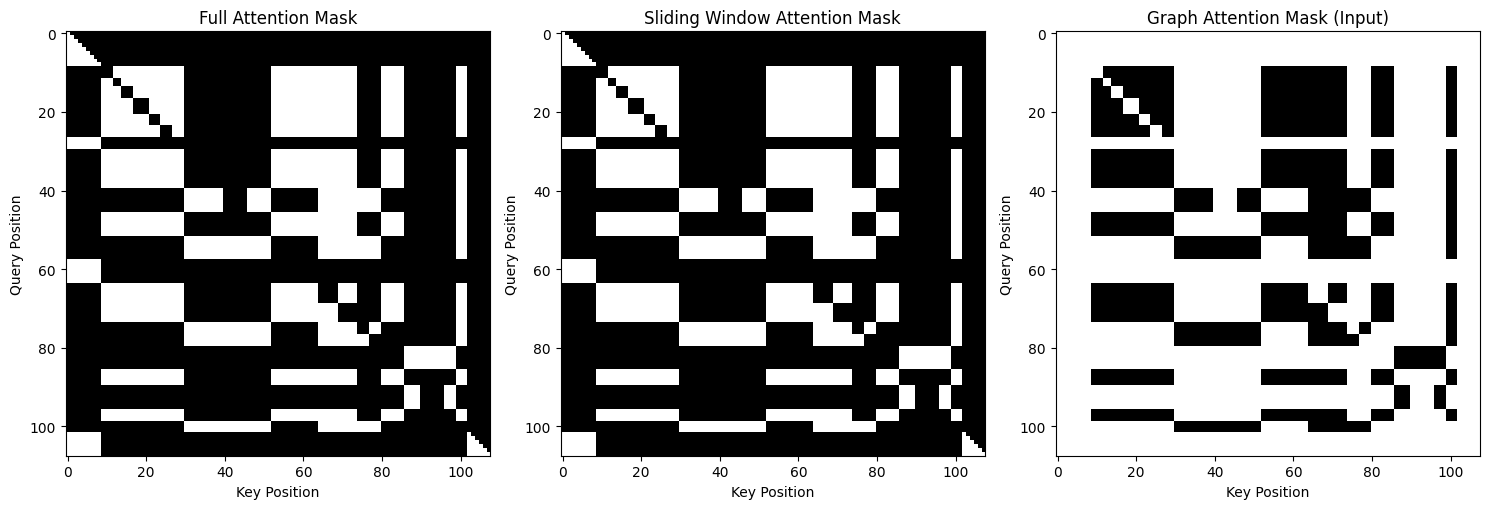

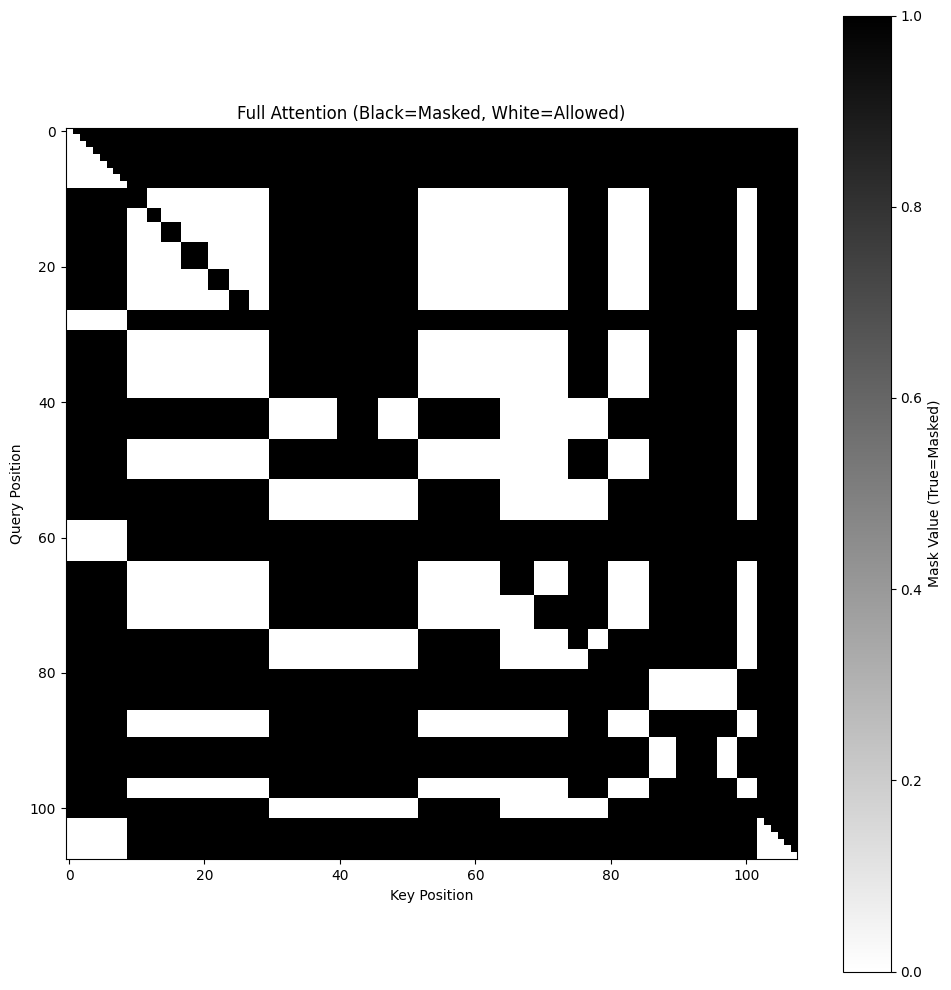

Attention Mask Statistics

full_attention:
  Shape: torch.Size([1, 1, 108, 108])
  Total elements: 11664
  Masked positions (True): 7999 (68.58%)
  Allowed positions (False): 3665 (31.42%)
  Dtype: torch.bool

sliding_attention:
  Shape: torch.Size([1, 1, 108, 108])
  Total elements: 11664
  Masked positions (True): 7999 (68.58%)
  Allowed positions (False): 3665 (31.42%)
  Dtype: torch.bool

graph_attention_mask_input:
  Shape: torch.Size([1, 108, 108])
  Total elements: 11664
  Masked positions (True): 3464 (29.70%)
  Allowed positions (False): 8200 (70.30%)
  Dtype: torch.bool
✓ Mask visualization disabled


In [5]:
# Import the visualization helpers
from visualize_masks import (
    enable_mask_visualization,
    disable_mask_visualization,
    visualize_attention_masks,
    visualize_combined_mask,
    print_mask_statistics
)

# 1. Enable mask visualization
enable_mask_visualization(model)


inputs.to(device)
# 2. Run a forward pass (this will capture the masks)
with torch.no_grad():
    
    output = model(**inputs)

# 3. Visualize all masks side by side
visualize_attention_masks(model, figsize=(15, 5))

# 4. Visualize a single mask in detail (like in practice.ipynb)
visualize_combined_mask(model, mask_type='full_attention', figsize=(10, 10))

# You can also visualize other masks:
# visualize_combined_mask(model, mask_type='sliding_attention', figsize=(10, 10))
# visualize_combined_mask(model, mask_type='graph_attention_mask', figsize=(10, 10))

# 5. Print statistics about the masks
print_mask_statistics(model)

# 6. When done, disable to save memory
disable_mask_visualization(model)

10/10
---



In [1]:
%load_ext autoreload
%autoreload 2
from plan_dataset import TaskPlanningDataset
from dataclasses import dataclass
from transformers import AutoTokenizer, AutoProcessor
import json
import torch


@dataclass
class Args:
    dataset="huggingface"


args = Args()
# plan_dataset = TaskPlanningDataset(args.dataset)



tool_list = json.load(open(f"../data/{args.dataset}/tool_desc.json", "r"))["nodes"]
link_list = json.load(open(f"../data/{args.dataset}/graph_desc.json", "r"))["links"]


/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
from transformers import AutoProcessor, Gemma3Processor

# --------------------------------------------------------------------------
# 1. DEFINE THE DYNAMIC, GRAPH-AWARE JINJA2 CHAT TEMPLATE
# --------------------------------------------------------------------------
# This template correctly formats the conversation without hard-coding special tokens.
CUSTOM_CHAT_TEMPLATE_FOR_GRAPH = """
{%- for message in messages -%}
    {{ bos_token }}
    {%- if message['role'] == 'user' -%}
        {{ '<start_of_turn>user\n' }}
        {%- if message['content'] is string -%}
            {{ message['content'] }}
        {%- else -%}
            {%- for part in message['content'] -%}
                {%- if part['type'] == 'text' -%}
                    {{ part['text'] }}
                {%- elif part['type'] == 'graph' -%}
                    {{ '<start_of_graph>'}}
                    {%- for node in part['nodes'] -%}
                        {{ '<node>' + node['id'] }}
                    {%- endfor -%}
                    {{ '<end_of_graph>' }}
                {%- endif -%}
            {%- endfor -%}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
    {%- elif message['role'] == 'assistant' -%}
        {{ '<start_of_turn>model\n' + message['content'] + '<end_of_turn>\n' }}
    {%- endif -%}
{%- endfor -%}
{%- if add_generation_prompt -%}
    {{ '<start_of_turn>model\n' }}
{%- endif -%}
"""

# --------------------------------------------------------------------------
# 2. DEFINE THE FINAL CUSTOM PROCESSOR
# --------------------------------------------------------------------------
class GraphGemma3Processor(Gemma3Processor):
    """
    The final processor. It correctly templates text/graph data AND
    generates the custom graph_attention_mask.
    """
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        self.tokenizer.add_special_tokens({"additional_special_tokens": ["[NODE]"]})
    
    def apply_chat_template(self, conversation, chat_template=None, **kwargs):
        """Overrides the base method to use our custom, graph-aware template."""
        if chat_template is None:
            chat_template = CUSTOM_CHAT_TEMPLATE_FOR_GRAPH
        return self.tokenizer.apply_chat_template(
            conversation, chat_template=chat_template, **kwargs
        )

    def __call__(self, conversation, **kwargs):
        """
        The main entry point. Orchestrates templating and custom mask creation.
        """
        # Step 1: Use our overridden template to get the base tokenized inputs
        # This will return a dictionary with 'input_ids' and 'attention_mask'.
        processed_inputs = self.apply_chat_template(
            conversation, tokenize=True, return_dict=True, **kwargs
        )
        
        graph_parts = [part for m in conversation for part in (m['content'] if isinstance(m['content'], list) else []) if part.get('type') == 'graph']
        
        print(f"graph_parts: {graph_parts}")

        # Step 2: If a graph was in the conversation, find its token spans and create the mask.
        if graph_parts:
            graph_data = graph_parts[0] # Assuming one graph block
            tool_token_spans = {}
            
            # To find the spans, we tokenize each node string and search for it
            # in the main input_ids tensor. This is a robust way to find exact positions.
            for node in graph_data["nodes"]:
                node_str = f"<node>{node['id']}"
                # Important: Do not add special tokens when tokenizing the substring
                node_tokens = self.tokenizer.encode(node_str, add_special_tokens=False)
                
                # Search for this sequence of tokens in the main input_ids
                main_ids = processed_inputs['input_ids'][0].tolist()
                node_ids = node_tokens
                
                for i in range(len(main_ids) - len(node_ids) + 1):
                    if main_ids[i:i+len(node_ids)] == node_ids:
                        start_idx = i
                        end_idx = i + len(node_ids)
                        tool_token_spans[node['id']] = (start_idx, end_idx)
                        break
            
            # Step 3: Build the graph_attention_mask using the found spans
            seq_len = processed_inputs["input_ids"].shape[1]
            graph_attention_mask = torch.zeros((seq_len, seq_len), dtype=torch.bool)
            
            for link in graph_data.get("links", []):
                source_id, target_id = link["source"], link["target"]
                if source_id in tool_token_spans and target_id in tool_token_spans:
                    source_start, source_end = tool_token_spans[source_id]
                    target_start, target_end = tool_token_spans[target_id]
                    graph_attention_mask[source_start:source_end, target_start:target_end] = True
            
            # Add the final mask to our output dictionary
            processed_inputs["graph_attention_mask"] = graph_attention_mask.unsqueeze(0)

        return processed_inputs


In [3]:

model_id = "google/gemma-3-4b-it"
original_processor = AutoProcessor.from_pretrained(model_id)


processor = GraphGemma3Processor(
    image_processor=original_processor.image_processor,
    tokenizer=original_processor.tokenizer
)

conversation_data = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Plan a trip using these tools."},
            {"type": "graph", 
                "nodes": tool_list, 
                "links": link_list
            }
        ]
    }
]

# --- A single call to the processor's __call__ method ---
final_inputs = processor(
    conversation=conversation_data,
    add_generation_prompt=True,
    return_tensors="pt"
)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


graph_parts: [{'type': 'graph', 'nodes': [{'id': 'Token Classification', 'desc': 'Token classification is a natural language understanding task in which a label is assigned to some tokens in a text. Some popular token classification subtasks are Named Entity Recognition (NER) and Part-of-Speech (PoS) tagging. NER models could be trained to identify specific entities in a text, such as dates, individuals and places; and PoS tagging would identify, for example, which words in a text are verbs, nouns, and punctuation marks.', 'input-type': ['text'], 'output-type': ['text']}, {'id': 'Translation', 'desc': 'Translation is the task of converting text from one language to another.', 'input-type': ['text'], 'output-type': ['text']}, {'id': 'Summarization', 'desc': 'Summarization is the task of producing a shorter version of a document while preserving its important information. Some models can extract text from the original input, while other models can generate entirely new text.', 'input-typ

In [4]:
final_inputs

{'input_ids': tensor([[     2,    105,   2364,    107,  21817,    496,   7946,   1699,   1239,
           6436,  21603,   3041, 236779,   1340, 236779,   8818,   1798,   5335,
         236813,   7211,  41173, 236820,   5335, 236813,  67830, 236820,   5335,
         236813, 160773,   1854, 236820,   5335, 236813,  14977,   1455,  35259,
         236820,   5335, 236813,  90309,   1353, 236820,   5335, 236813,   2067,
          32955, 236820,   5335, 236813, 138895, 206043, 236820,   5335, 236813,
           7874,   1153,  41173, 236820,   5335, 236813,   3372,  49549, 236820,
           5335, 236813,   1779,  41173, 236820,   5335, 236813,   1779, 236772,
           1071, 236772,   1779, 236820,   5335, 236813,   1779, 236772,   1071,
         236772,   2067, 236820,   5335, 236813,   2067, 236772,   1071, 236772,
           1779, 236820,   5335, 236813,   2067, 236772,   1071, 236772,  10485,
         236820,   5335, 236813,  20216,  19566,   1455,  35259, 236820,   5335,
         23681

In [5]:
list(final_inputs.keys())

['input_ids', 'attention_mask', 'graph_attention_mask']

In [6]:
decoded_text = processor.decode(final_inputs['input_ids'][0])
print(decoded_text)

<bos><start_of_turn>user
Plan a trip using these tools.<start_of_graph><node>Token Classification<node>Translation<node>Summarization<node>Question Answering<node>Conversational<node>Text Generation<node>Sentence Similarity<node>Tabular Classification<node>Object Detection<node>Image Classification<node>Image-to-Image<node>Image-to-Text<node>Text-to-Image<node>Text-to-Video<node>Visual Question Answering<node>Document Question Answering<node>Image Segmentation<node>Depth Estimation<node>Text-to-Speech<node>Automatic Speech Recognition<node>Audio-to-Audio<node>Audio Classification<node>Image Editing<end_of_graph><end_of_turn>
<start_of_turn>model



In [7]:
final_inputs.graph_attention_mask[0].sum()

tensor(7169)

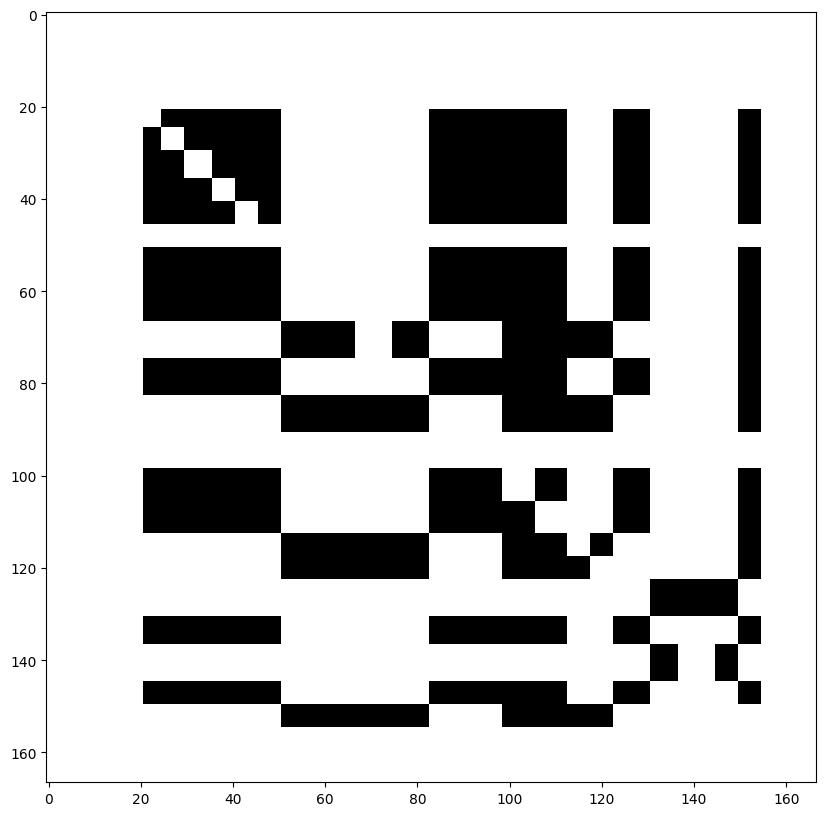

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization Code ---
fig, ax = plt.subplots(figsize=(10, 10))
# Use imshow with the 'binary' colormap (True=black, False=white)
cax = ax.imshow(final_inputs.graph_attention_mask[0], cmap='binary', interpolation='none')

In [ ]:
import torch
from transformers import AutoProcessor, Gemma3Processor

# --------------------------------------------------------------------------
# 1. DEFINE THE DYNAMIC, GRAPH-AWARE JINJA2 CHAT TEMPLATE
# --------------------------------------------------------------------------
# This template correctly formats the conversation without hard-coding special tokens.
CUSTOM_CHAT_TEMPLATE_FOR_GRAPH = """
{%- for message in messages -%}
    {{ bos_token }}
    {%- if message['role'] == 'user' -%}
        {{ '<start_of_turn>user\n' }}
        {%- if message['content'] is string -%}
            {{ message['content'] }}
        {%- else -%}
            {%- for part in message['content'] -%}
                {%- if part['type'] == 'text' -%}
                    {{ part['text'] }}
                {%- elif part['type'] == 'graph' -%}
                    {{ '<start_of_graph>'}}
                    {%- for node in part['nodes'] -%}
                        {{ '<node>' + node['id'] }}
                    {%- endfor -%}
                    {{ '<end_of_graph>' }}
                {%- endif -%}
            {%- endfor -%}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
    {%- elif message['role'] == 'assistant' -%}
        {{ '<start_of_turn>model\n' + message['content'] + '<end_of_turn>\n' }}
    {%- endif -%}
{%- endfor -%}
{%- if add_generation_prompt -%}
    {{ '<start_of_turn>model\n' }}
{%- endif -%}
"""

# --------------------------------------------------------------------------
# 2. DEFINE THE FINAL CUSTOM PROCESSOR
# --------------------------------------------------------------------------
class GraphGemma3Processor(Gemma3Processor):
    """
    The final processor. It correctly templates text/graph data,
    generates the custom graph_attention_mask, AND the token_type_ids.
    """
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        # Add all custom tokens used in the template for correctness
        self.tokenizer.add_special_tokens({
            "additional_special_tokens": ["<start_of_graph>", "<end_of_graph>", "<node>"]
        })

    def apply_chat_template(self, conversation, chat_template=None, **kwargs):
        """Overrides the base method to use our custom, graph-aware template."""
        if chat_template is None:
            chat_template = CUSTOM_CHAT_TEMPLATE_FOR_GRAPH
        return self.tokenizer.apply_chat_template(
            conversation, chat_template=chat_template, **kwargs
        )

    def _find_subsequence(self, main_list, sub_list):
        """Helper to find the start index of a subsequence."""
        for i in range(len(main_list) - len(sub_list) + 1):
            if main_list[i:i+len(sub_list)] == sub_list:
                return i
        return None

    def __call__(self, conversation, **kwargs):
        """
        The main entry point. Orchestrates templating and custom mask/id creation.
        """
        # Step 1: Render the conversation object into a single string using the template.
        # We set tokenize=False because we only want the formatted string for now.
        prompt_string = self.apply_chat_template(conversation, tokenize=False)

        # Step 2: Pass the formatted string to the parent __call__ method.
        # This is the robust way to ensure correct tokenization and handling.
        processed_inputs = super().__call__(text=prompt_string, return_tensors="pt", **kwargs)

        # Step 3: Create the token_type_ids tensor, defaulting to 0 (text).
        token_type_ids = torch.zeros_like(processed_inputs["input_ids"])

        # Step 4: Find graph parts and update token_type_ids to 2.
        graph_parts = [
            part for m in conversation 
            for part in (m['content'] if isinstance(m['content'], list) else []) 
            if part.get('type') == 'graph'
        ]

        if graph_parts:
            main_ids = processed_inputs['input_ids'][0].tolist()
            sog_tokens = self.tokenizer.encode('<start_of_graph>', add_special_tokens=False)
            eog_tokens = self.tokenizer.encode('<end_of_graph>', add_special_tokens=False)
            graph_start_idx = self._find_subsequence(main_ids, sog_tokens)
            graph_end_idx_exclusive = self._find_subsequence(main_ids, eog_tokens)
            
            if graph_start_idx is not None and graph_end_idx_exclusive is not None:
                graph_end_idx_inclusive = graph_end_idx_exclusive + len(eog_tokens)
                token_type_ids[:, graph_start_idx:graph_end_idx_inclusive] = 2

            # --- Logic for the graph_attention_mask ---
            graph_data = graph_parts[0]
            node_token_spans = {}
            for node in graph_data["nodes"]:
                node_str = f"<node>{node['id']}"
                node_tokens = self.tokenizer.encode(node_str, add_special_tokens=False)
                start_idx = self._find_subsequence(main_ids, node_tokens)
                if start_idx is not None:
                    node_token_spans[node['id']] = (start_idx, start_idx + len(node_tokens))

            seq_len = processed_inputs["input_ids"].shape[1]
            graph_attention_mask = torch.zeros((seq_len, seq_len), dtype=torch.bool)
            
            for link in graph_data.get("links", []):
                source_id, target_id = link["source"], link["target"]
                if source_id in node_token_spans and target_id in node_token_spans:
                    source_start, source_end = node_token_spans[source_id]
                    target_start, target_end = node_token_spans[target_id]
                    graph_attention_mask[source_start:source_end, target_start:target_end] = True
            
            processed_inputs["graph_attention_mask"] = graph_attention_mask.unsqueeze(0)
            processed_inputs["token_type_ids"] = token_type_ids

        return processed_inputs

# --------------------------------------------------------------------------
# 3. EXAMPLE USAGE
# --------------------------------------------------------------------------
if __name__ == '__main__':
    model_id = "google/gemma-3-4b-it" # Using the 4b model as in your example
    
    # We need a real processor to get the image_processor and tokenizer
    base_processor = AutoProcessor.from_pretrained(model_id)

    # Instantiate our custom processor
    processor = GraphGemma3Processor(
        image_processor=base_processor.image_processor,
        tokenizer=base_processor.tokenizer
    )

    # Define a conversation with text and a graph
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Analyze this graph:"},
                {
                    "type": "graph",
                    "nodes": [{"id": "A"}, {"id": "B"}],
                    "links": [{"source": "A", "target": "B"}]
                }
            ]
        }
    ]

    # Process the conversation
    inputs = processor(conversation=conversation)

    # Print the results to verify
    print("--- Decoded Tokens ---")
    print(processor.tokenizer.decode(inputs["input_ids"][0]))
    print("\n--- Token Type IDs ---")
    print(inputs["token_type_ids"])
    print("\nShape:", inputs["token_type_ids"].shape)

--- Decoded Tokens ---
<bos><bos><start_of_turn>user
Analyze this graph:<start_of_graph><node>A<node>B<end_of_graph><end_of_turn>


--- Token Type IDs ---
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0]])

Shape: torch.Size([1, 17])


In [27]:

model_id = "google/gemma-3-4b-it"
original_processor = AutoProcessor.from_pretrained(model_id)


processor = GraphGemma3Processor(
    image_processor=original_processor.image_processor,
    tokenizer=original_processor.tokenizer
)

conversation_data = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Plan a trip using these tools."},
            {"type": "graph", 
                "nodes": tool_list, 
                "links": link_list
            }
        ]
    }
]

# --- A single call to the processor's __call__ method ---
final_inputs = processor(
    conversation=conversation_data
)


In [34]:
print(processor.decode(final_inputs['input_ids'][0]))

<bos><bos><start_of_turn>user
Plan a trip using these tools.<start_of_graph><node>Token Classification<node>Translation<node>Summarization<node>Question Answering<node>Conversational<node>Text Generation<node>Sentence Similarity<node>Tabular Classification<node>Object Detection<node>Image Classification<node>Image-to-Image<node>Image-to-Text<node>Text-to-Image<node>Text-to-Video<node>Visual Question Answering<node>Document Question Answering<node>Image Segmentation<node>Depth Estimation<node>Text-to-Speech<node>Automatic Speech Recognition<node>Audio-to-Audio<node>Audio Classification<node>Image Editing<end_of_graph><end_of_turn>



In [31]:
list(final_inputs.keys())

['input_ids', 'attention_mask', 'token_type_ids', 'graph_attention_mask']

In [33]:
final_inputs.graph_attention_mask.shape

torch.Size([1, 109, 109])

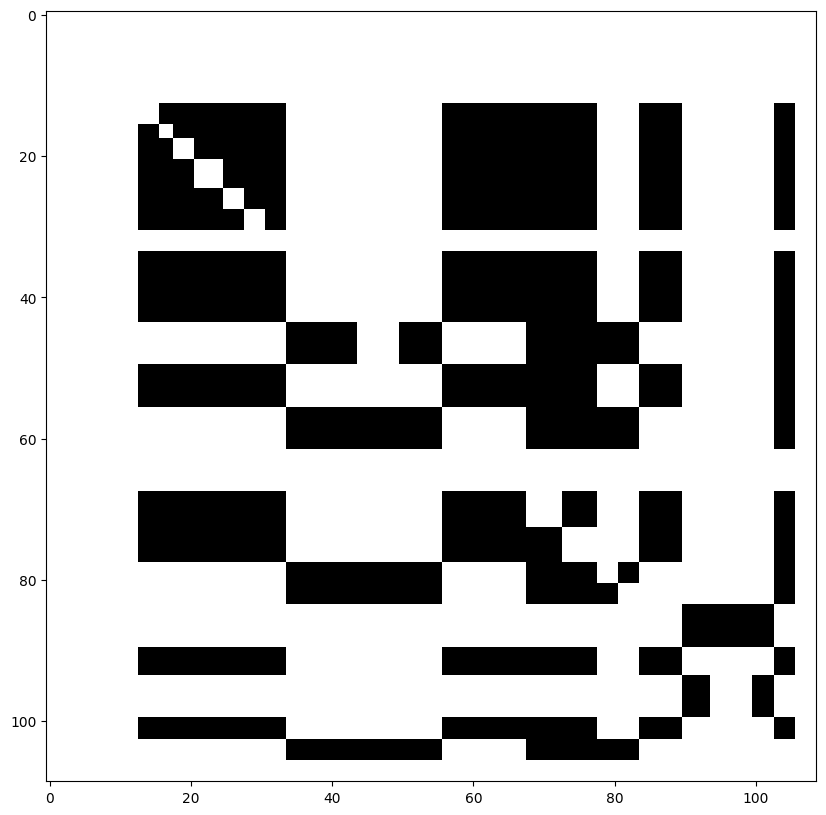

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization Code ---
fig, ax = plt.subplots(figsize=(10, 10))
# Use imshow with the 'binary' colormap (True=black, False=white)
cax = ax.imshow(final_inputs.graph_attention_mask[0], cmap='binary', interpolation='none')

In [6]:
# CORRECTED TEMPLATE
CUSTOM_CHAT_TEMPLATE_FOR_GRAPH = """
{%- for message in messages -%}
    {%- if message['role'] == 'user' -%}
        {{ '<start_of_turn>user\n' }}
        {%- if message['content'] is string -%}
            {{ message['content'] }}
        {%- else -%}
            {%- for part in message['content'] -%}
                {%- if part['type'] == 'text' -%}
                    {{ part['text'] }}
                {%- elif part['type'] == 'graph' -%}
                    {{ '<start_of_graph>'}}
                    {%- for node in part['nodes'] -%}
                        {{ '<node>' + node['id'] }}
                    {%- endfor -%}
                    {{ '<end_of_graph>' }}
                {%- endif -%}
            {%- endfor -%}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
    {%- elif message['role'] == 'assistant' -%}
        {{ '<start_of_turn>model\n' + message['content'] + '<end_of_turn>\n' }}
    {%- endif -%}
{%- endfor -%}
{%- if add_generation_prompt -%}
    {{ '<start_of_turn>model\n' }}
{%- endif -%}
"""


import torch
from transformers import AutoProcessor, Gemma3Processor

# [PASTE THE CORRECTED TEMPLATE FROM ABOVE HERE]

class GraphGemma3Processor(Gemma3Processor):
    """
    The final processor. It correctly templates text/graph data,
    generates the custom graph_attention_mask, AND the token_type_ids.
    """
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        self.tokenizer.add_special_tokens({
            "additional_special_tokens": ["<start_of_graph>", "<end_of_graph>", "<node>"]
        })

    def apply_chat_template(self, conversation, chat_template=None, **kwargs):
        if chat_template is None:
            chat_template = CUSTOM_CHAT_TEMPLATE_FOR_GRAPH
        return self.tokenizer.apply_chat_template(
            conversation, chat_template=chat_template, **kwargs
        )

    def _find_subsequence(self, main_list, sub_list):
        for i in range(len(main_list) - len(sub_list) + 1):
            if main_list[i:i+len(sub_list)] == sub_list:
                return i
        return None

    def __call__(self, conversation, **kwargs):
        """
        The main entry point. Orchestrates templating and custom mask/id creation.
        """
        # Step 1: Render the conversation into a string.
        # Pass **kwargs to ensure `add_generation_prompt` is handled.
        prompt_string = self.apply_chat_template(conversation, tokenize=False, **kwargs)

        # Step 2: Pass the formatted string to the parent __call__ method.
        processed_inputs = super().__call__(text=prompt_string, return_tensors="pt", **kwargs)

        # Step 3: Create the token_type_ids tensor.
        token_type_ids = torch.zeros_like(processed_inputs["input_ids"])

        # Step 4: Find graph parts and update token_type_ids to 2.
        graph_parts = [
            part for m in conversation 
            for part in (m['content'] if isinstance(m['content'], list) else []) 
            if part.get('type') == 'graph'
        ]

        if graph_parts:
            main_ids = processed_inputs['input_ids'][0].tolist()
            sog_tokens = self.tokenizer.encode('<start_of_graph>', add_special_tokens=False)
            eog_tokens = self.tokenizer.encode('<end_of_graph>', add_special_tokens=False)
            graph_start_idx = self._find_subsequence(main_ids, sog_tokens)
            graph_end_idx_exclusive = self._find_subsequence(main_ids, eog_tokens)
            
            if graph_start_idx is not None and graph_end_idx_exclusive is not None:
                graph_end_idx_inclusive = graph_end_idx_exclusive + len(eog_tokens)
                token_type_ids[:, graph_start_idx:graph_end_idx_inclusive] = 2

            graph_data = graph_parts[0]
            node_token_spans = {}
            for node in graph_data["nodes"]:
                node_str = f"<node>{node['id']}"
                node_tokens = self.tokenizer.encode(node_str, add_special_tokens=False)
                start_idx = self._find_subsequence(main_ids, node_tokens)
                if start_idx is not None:
                    node_token_spans[node['id']] = (start_idx, start_idx + len(node_tokens))

            seq_len = processed_inputs["input_ids"].shape[1]
            graph_attention_mask = torch.zeros((seq_len, seq_len), dtype=torch.bool)
            
            for link in graph_data.get("links", []):
                source_id, target_id = link["source"], link["target"]
                if source_id in node_token_spans and target_id in node_token_spans:
                    source_start, source_end = node_token_spans[source_id]
                    target_start, target_end = node_token_spans[target_id]
                    graph_attention_mask[source_start:source_end, target_start:target_end] = True
            
            processed_inputs["graph_attention_mask"] = graph_attention_mask.unsqueeze(0)
            processed_inputs["token_type_ids"] = token_type_ids

        return processed_inputs
    
    
    



In [7]:
if __name__ == '__main__':
    model_id = "google/gemma-3-4b-it"
    base_processor = AutoProcessor.from_pretrained(model_id)

    processor = GraphGemma3Processor(
        image_processor=base_processor.image_processor,
        tokenizer=base_processor.tokenizer
    )

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Analyze this graph:"},
                {
                    "type": "graph",
                    "nodes": tool_list,
                    "links": link_list
                }
            ]
        }
    ]

    # Process the conversation with the generation prompt enabled
    inputs = processor(conversation=conversation, add_generation_prompt=True)

    # Print the results to verify
    print("--- Decoded Tokens ---")
    print(processor.tokenizer.decode(inputs["input_ids"][0]))
    print("\n--- Token Type IDs ---")
    print(inputs["token_type_ids"])

Keyword argument `add_generation_prompt` is not a valid argument for this processor and will be ignored.


--- Decoded Tokens ---
<bos><start_of_turn>user
Analyze this graph:<start_of_graph><node>Token Classification<node>Translation<node>Summarization<node>Question Answering<node>Conversational<node>Text Generation<node>Sentence Similarity<node>Tabular Classification<node>Object Detection<node>Image Classification<node>Image-to-Image<node>Image-to-Text<node>Text-to-Image<node>Text-to-Video<node>Visual Question Answering<node>Document Question Answering<node>Image Segmentation<node>Depth Estimation<node>Text-to-Speech<node>Automatic Speech Recognition<node>Audio-to-Audio<node>Audio Classification<node>Image Editing<end_of_graph><end_of_turn>
<start_of_turn>model


--- Token Type IDs ---
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [8]:
list(inputs.keys())

['input_ids', 'attention_mask', 'token_type_ids', 'graph_attention_mask']

In [39]:
inputs.graph_attention_mask.sum()

tensor(3464)

In [ ]:
# File: custom_gemma3.py

from typing import Optional, Callable
import torch
import torch.nn as nn

from transformers import Gemma3ForConditionalGeneration, Gemma3Model
from transformers.models.gemma3.modeling_gemma3 import (
    create_masks_for_generate,
    Gemma3Config,
    BaseModelOutputWithPast
)

# -----------------------------------------------------------------------------------
# 1. DEFINE YOUR CUSTOM MASKING LOGIC
# (These two functions are the same as before)
# -----------------------------------------------------------------------------------

def token_type_ids_mask_function(
    token_type_ids: Optional[torch.Tensor],
    image_group_ids: Optional[torch.Tensor],
    graph_attention_mask: Optional[torch.Tensor],
) -> Optional[Callable]:
    # ... (code from the previous answer, no changes needed here)
    if token_type_ids is None:
        return None

    def inner_mask(batch_idx: int, head_idx: int, q_idx: int, kv_idx: int) -> bool:
        safe_idx = torch.where(kv_idx < token_type_ids.shape[1], kv_idx, 0)
        token_type_ids_at_kv_idx = token_type_ids[batch_idx, safe_idx]
        token_type_ids_at_kv_idx = torch.where(kv_idx < token_type_ids.shape[1], token_type_ids_at_kv_idx, 0)
        image_group_ids_at_kv_idx = image_group_ids[batch_idx, safe_idx]
        image_group_ids_at_kv_idx = torch.where(kv_idx < image_group_ids.shape[1], image_group_ids_at_kv_idx, -1)
        is_image_block = (token_type_ids[batch_idx, q_idx] == 1) & (token_type_ids_at_kv_idx == 1)
        same_image_block = image_group_ids[batch_idx, q_idx] == image_group_ids_at_kv_idx
        allow_image_attention = is_image_block & same_image_block
        allow_graph_attention = torch.tensor(False, device=token_type_ids.device)
        if graph_attention_mask is not None:
            is_graph_block = (token_type_ids[batch_idx, q_idx] == 2) & (token_type_ids_at_kv_idx == 2)
            is_connected_in_graph = torch.where(
                (q_idx < graph_attention_mask.shape[1]) & (kv_idx < graph_attention_mask.shape[2]),
                graph_attention_mask[batch_idx, q_idx, kv_idx],
                torch.tensor(False, device=graph_attention_mask.device)
            )
            allow_graph_attention = is_graph_block & is_connected_in_graph
        return allow_image_attention | allow_graph_attention
    return inner_mask

def create_graph_causal_mask_mapping(
    config: Gemma3Config,
    input_embeds: torch.Tensor,
    attention_mask: Optional[torch.Tensor],
    cache_position: torch.Tensor,
    past_key_values: Optional[object],
    position_ids: Optional[torch.Tensor],
    token_type_ids: Optional[torch.Tensor] = None,
    pixel_values: Optional[torch.FloatTensor] = None,
    graph_attention_mask: Optional[torch.Tensor] = None,
    is_training: bool = False,
    **kwargs,
) -> dict:
    # ... (code from the previous answer, no changes needed here)
    if is_training and token_type_ids is None:
        raise ValueError("`token_type_ids` is required as a model input when training")
    mask_kwargs = {
        "config": config.get_text_config(),
        "input_embeds": input_embeds,
        "attention_mask": attention_mask,
        "cache_position": cache_position,
        "past_key_values": past_key_values,
        "position_ids": position_ids,
    }
    if token_type_ids is not None:
        is_image = (token_type_ids == 1).to(cache_position.device)
        is_previous_image = nn.functional.pad(is_image, (1, 0), value=0)[:, :-1]
        new_image_start = is_image & ~is_previous_image
        image_group_ids = torch.cumsum(new_image_start.int(), dim=1) - 1
        image_group_ids = torch.where(is_image, image_group_ids, torch.full_like(token_type_ids, -1))
        mask_kwargs["or_mask_function"] = token_type_ids_mask_function(
            token_type_ids.to(cache_position.device),
            image_group_ids,
            graph_attention_mask,
        )
    return create_masks_for_generate(**mask_kwargs)



# File: custom_gemma3.py

from typing import Optional, Callable
import torch
import torch.nn as nn

from transformers import Gemma3ForConditionalGeneration, Gemma3Model
# MODIFICATION START: Import the correct output class
from transformers.models.gemma3.modeling_gemma3 import (
    create_masks_for_generate,
    Gemma3Config,
    Gemma3ModelOutputWithPast  # <-- IMPORT THIS
)
# MODIFICATION END

# ... (The two masking functions, `token_type_ids_mask_function` and 
#      `create_graph_causal_mask_mapping`, remain exactly the same as before) ...

# -----------------------------------------------------------------------------------
# 2. CREATE THE CUSTOM `GraphGemma3Model`
# -----------------------------------------------------------------------------------
class GraphGemma3Model(Gemma3Model):
    def forward(
        self,
        input_ids: Optional[torch.LongTensor] = None,
        pixel_values: Optional[torch.FloatTensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[object] = None,
        token_type_ids: Optional[torch.LongTensor] = None,
        graph_attention_mask: Optional[torch.Tensor] = None, # <-- ADDED ARGUMENT
        cache_position: Optional[torch.LongTensor] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        **lm_kwargs,
    ):
        # --- (The first part of this method, which prepares inputs and
        #      calls create_graph_causal_mask_mapping, is correct and remains the same) ---
        
        # --- Start: Copied from original Gemma3Model.forward ---
        if (input_ids is None) ^ (inputs_embeds is not None):
            raise ValueError("You must specify exactly one of input_ids or inputs_embeds")

        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        image_features = None # Define here for the return statement

        if input_ids is not None and self.config.image_token_id >= self.vocab_size:
            special_image_mask = input_ids == self.config.image_token_id
            llm_input_ids = input_ids.clone()
            llm_input_ids[special_image_mask] = 0
        else:
            llm_input_ids = input_ids

        if inputs_embeds is None:
            inputs_embeds = self.get_input_embeddings()(llm_input_ids)

        if cache_position is None:
            past_seen_tokens = past_key_values.get_seq_length() if past_key_values is not None else 0
            cache_position = torch.arange(
                past_seen_tokens, past_seen_tokens + inputs_embeds.shape[1], device=inputs_embeds.device
            )

        if pixel_values is not None:
            image_features = self.get_image_features(pixel_values)
            image_features = image_features.to(inputs_embeds.device, inputs_embeds.dtype)
            special_image_mask = self.get_placeholder_mask(
                input_ids, inputs_embeds=inputs_embeds, image_features=image_features
            )
            inputs_embeds = inputs_embeds.masked_scatter(special_image_mask, image_features)
        
        if not isinstance(causal_mask_mapping := attention_mask, dict):
            causal_mask_mapping = create_graph_causal_mask_mapping(
                self.config,
                inputs_embeds,
                attention_mask,
                cache_position,
                past_key_values,
                position_ids,
                token_type_ids,
                pixel_values,
                graph_attention_mask=graph_attention_mask,
                is_training=self.training,
            )

        outputs = self.language_model(
            attention_mask=causal_mask_mapping,
            position_ids=position_ids,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=True,
            cache_position=cache_position,
            **lm_kwargs,
        )

        # MODIFICATION START: Return the correct object type
        return Gemma3ModelOutputWithPast(
            last_hidden_state=outputs.last_hidden_state,
            past_key_values=outputs.past_key_values if use_cache else None,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
            image_hidden_states=image_features if pixel_values is not None else None,
        )
        # MODIFICATION END


# File: custom_gemma3.py

# ... (Keep the imports and the two masking functions as they were)
# ... (Keep the GraphGemma3Model class as it was)

# -----------------------------------------------------------------------------------
# 3. CREATE THE FINAL TOP-LEVEL CLASS (WITH THE CORRECTED FORWARD SIGNATURE)
# -----------------------------------------------------------------------------------
class GraphGemma3ForConditionalGeneration(Gemma3ForConditionalGeneration):
    def __init__(self, config: Gemma3Config):
        super().__init__(config)
        self.model = GraphGemma3Model(config)

    # MODIFICATION: The signature of this `forward` method now explicitly lists all
    # the arguments from the original class, plus our new `graph_attention_mask`.
    # This makes it pass the `generate` method's validation check.
    def forward(
        self,
        input_ids: Optional[torch.LongTensor] = None,
        pixel_values: Optional[torch.FloatTensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[object] = None,
        token_type_ids: Optional[torch.LongTensor] = None,
        graph_attention_mask: Optional[torch.Tensor] = None, # <-- OUR ARGUMENT
        cache_position: Optional[torch.LongTensor] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        **kwargs,
    ):
        # We now pass all arguments explicitly to the parent's `forward` method.
        return super().forward(
            input_ids=input_ids,
            pixel_values=pixel_values,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            token_type_ids=token_type_ids,
            graph_attention_mask=graph_attention_mask, # <-- PASSING IT ALONG
            cache_position=cache_position,
            inputs_embeds=inputs_embeds,
            labels=labels,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            **kwargs,
        )

    def prepare_inputs_for_generation(self, *args, **kwargs):
        # This function remains the same and is still necessary.
        graph_attention_mask = kwargs.pop("graph_attention_mask", None)
        model_inputs = super().prepare_inputs_for_generation(*args, **kwargs)
        model_inputs["graph_attention_mask"] = graph_attention_mask
        return model_inputs

In [49]:
model_id = "google/gemma-3-4b-it"
base_processor = AutoProcessor.from_pretrained(model_id)

processor = GraphGemma3Processor(
    image_processor=base_processor.image_processor,
    tokenizer=base_processor.tokenizer
)

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Analyze this graph:"},
            {
                "type": "graph",
                "nodes": tool_list,
                "links": link_list
            }
        ]
    }
]

# Process the conversation with the generation prompt enabled
inputs = processor(conversation=conversation, add_generation_prompt=True)




In [46]:
inputs

{'input_ids': tensor([[     2,    105,   2364,    107, 115863,    672,   3753, 236787, 262145,
         262147,   7211,  41173, 262147,  67830, 262147, 160773,   1854, 262147,
          14977,   1455,  35259, 262147,  90309,   1353, 262147,   2067,  32955,
         262147, 138895, 206043, 262147,   7874,   1153,  41173, 262147,   3372,
          49549, 262147,   1779,  41173, 262147,   1779, 236772,   1071, 236772,
           1779, 262147,   1779, 236772,   1071, 236772,   2067, 262147,   2067,
         236772,   1071, 236772,   1779, 262147,   2067, 236772,   1071, 236772,
          10485, 262147,  20216,  19566,   1455,  35259, 262147,  15124,  19566,
           1455,  35259, 262147,   1779, 191513, 262147,  40255,  88098, 262147,
           2067, 236772,   1071, 236772,  75289, 262147,  78850,  50937,  77021,
         262147,  23994, 236772,   1071, 236772,  23994, 262147,  23994,  41173,
         262147,   1779,  84226, 262146,    106,    107,    105,   4368,    107]]), 'attention_

In [59]:
model = GraphGemma3ForConditionalGeneration.from_pretrained(model_id)
model.resize_token_embeddings(len(processor.tokenizer))

Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.88s/it]


Gemma3TextScaledWordEmbedding(262148, 2560, padding_idx=0)

In [60]:
logits = model(**inputs)

In [66]:
logits.logits.shape

torch.Size([1, 108, 262148])

In [61]:
out = model.generate(**inputs)

RuntimeError: index 80603 is out of bounds for dimension 1 with size 108

## 10/9

In [ ]:
%load_ext autoreload
%autoreload 2
from plan_dataset import TaskPlanningDataset
from dataclasses import dataclass
from transformers import AutoTokenizer


@dataclass
class Args:
    dataset="huggingface"



args = Args()
plan_dataset = TaskPlanningDataset(args.dataset)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
d = next(iter(plan_dataset))

In [9]:
print(d['request'])

# TASK LIST #:
{"id": "Token Classification", "desc": "Token classification is a natural language understanding task in which a label is assigned to some tokens in a text. Some popular token classification subtasks are Named Entity Recognition (NER) and Part-of-Speech (PoS) tagging. NER models could be trained to identify specific entities in a text, such as dates, individuals and places; and PoS tagging would identify, for example, which words in a text are verbs, nouns, and punctuation marks.", "input-type": ["text"], "output-type": ["text"]}
{"id": "Translation", "desc": "Translation is the task of converting text from one language to another.", "input-type": ["text"], "output-type": ["text"]}
{"id": "Summarization", "desc": "Summarization is the task of producing a shorter version of a document while preserving its important information. Some models can extract text from the original input, while other models can generate entirely new text.", "input-type": ["text"], "output-type": 

In [5]:
llm_name = "google/gemma-3-4b-it"
tokenizer = AutoTokenizer.from_pretrained(llm_name)

In [ ]:
import json
import torch


tool_list = json.load(open(f"../data/{args.dataset}/tool_desc.json", "r"))["nodes"]

tool_prompt_tokens = []
tool_token_positions = {}


prefix = "# TASK LIST #:\n"
tool_prompt_tokens.extend(tokenizer(prefix, add_special_tokens=False)['input_ids'])


for tool in tool_list:
    # IMPORTANT: Record the position *before* adding the new tool's tokens
    # The position is relative to the start of the entire prompt
    tool_name = tool['id']
    tool_token_positions[tool_name] = len(tool_prompt_tokens)
    
    tool_str = json.dumps(tool) + "\n"
    tool_prompt_tokens.extend(tokenizer(tool_str, add_special_tokens=False)['input_ids'])
    
    
link_list = json.load(open(f"../data/{args.dataset}/graph_desc.json", "r"))["links"]
num_tool_tokens = len(tool_prompt_tokens)
        


base_graph_mask = torch.zeros((num_tool_tokens, num_tool_tokens), dtype=torch.bool)

for link in link_list:
    source_name, target_name = link["source"], link["target"]
    if source_name in tool_token_positions and target_name in tool_token_positions:
        source_idx = tool_token_positions[source_name]
        target_idx = tool_token_positions[target_name]
        
        base_graph_mask[source_idx, target_idx] = True

In [6]:
import json
import torch
# Assuming 'tokenizer' and 'args' are defined from your script's setup

# Load tool and graph descriptions
tool_list = json.load(open(f"../data/{args.dataset}/tool_desc.json", "r"))["nodes"]
link_list = json.load(open(f"../data/{args.dataset}/graph_desc.json", "r"))["links"]

tool_prompt_tokens = []
# MODIFICATION 1: Change to a dictionary that will store token spans (start, end)
tool_token_spans = {}

# Tokenize the prefix as before
prefix = "# TASK LIST #:\n"
tool_prompt_tokens.extend(tokenizer(prefix, add_special_tokens=False)['input_ids'])

# MODIFICATION 2: Loop to calculate and store the full token span for each tool
for tool in tool_list:
    # The key for the dictionary, using 'id' from your original code
    tool_name = tool['id'] 
    
    # Record the start position *before* adding the new tool's tokens
    start_idx = len(tool_prompt_tokens)
    
    # Tokenize the tool's JSON string and add its tokens to the main list
    tool_str = json.dumps(tool['id']) + "\n"
    tool_prompt_tokens.extend(tokenizer(tool_str, add_special_tokens=False)['input_ids'])
    
    # Record the end position, which is the new total length of the token list
    end_idx = len(tool_prompt_tokens)
    
    # Store the complete (start, end) span for the tool
    tool_token_spans[tool_name] = (start_idx, end_idx)
    
# Create the base graph mask
num_tool_tokens = len(tool_prompt_tokens)
base_graph_mask = torch.zeros((num_tool_tokens, num_tool_tokens), dtype=torch.bool)

# MODIFICATION 3: Loop to populate the mask using the token spans and slicing
for link in link_list:
    source_name, target_name = link["source"], link["target"]
    
    # Check if both source and target tools were successfully processed
    if source_name in tool_token_spans and target_name in tool_token_spans:
        
        # Retrieve the (start, end) spans for both tools
        source_start, source_end = tool_token_spans[source_name]
        target_start, target_end = tool_token_spans[target_name]
        
        # Use slicing to mark the entire directional block from source to target as True.
        # This makes every token of the source tool attend to every token of the target tool.
        base_graph_mask[source_start:source_end, target_start:target_end] = True

In [17]:
tool_file = f"../data/huggingface/tool_desc.json"
tool_str = ", ".join([tool['id'] for tool in json.load(open(tool_file, 'r'))['nodes']])


TypeError: can only concatenate str (not "list") to str

In [15]:
tool_str

'Token Classification, Translation, Summarization, Question Answering, Conversational, Text Generation, Sentence Similarity, Tabular Classification, Object Detection, Image Classification, Image-to-Image, Image-to-Text, Text-to-Image, Text-to-Video, Visual Question Answering, Document Question Answering, Image Segmentation, Depth Estimation, Text-to-Speech, Automatic Speech Recognition, Audio-to-Audio, Audio Classification, Image Editing'

In [16]:
tool_list

[{'id': 'Token Classification',
  'desc': 'Token classification is a natural language understanding task in which a label is assigned to some tokens in a text. Some popular token classification subtasks are Named Entity Recognition (NER) and Part-of-Speech (PoS) tagging. NER models could be trained to identify specific entities in a text, such as dates, individuals and places; and PoS tagging would identify, for example, which words in a text are verbs, nouns, and punctuation marks.',
  'input-type': ['text'],
  'output-type': ['text']},
 {'id': 'Translation',
  'desc': 'Translation is the task of converting text from one language to another.',
  'input-type': ['text'],
  'output-type': ['text']},
 {'id': 'Summarization',
  'desc': 'Summarization is the task of producing a shorter version of a document while preserving its important information. Some models can extract text from the original input, while other models can generate entirely new text.',
  'input-type': ['text'],
  'output

In [9]:
len(tool_prompt_tokens)

144

In [11]:
tokenizer.decode(tool_prompt_tokens)

'# TASK LIST #:\n"Token Classification"\n"Translation"\n"Summarization"\n"Question Answering"\n"Conversational"\n"Text Generation"\n"Sentence Similarity"\n"Tabular Classification"\n"Object Detection"\n"Image Classification"\n"Image-to-Image"\n"Image-to-Text"\n"Text-to-Image"\n"Text-to-Video"\n"Visual Question Answering"\n"Document Question Answering"\n"Image Segmentation"\n"Depth Estimation"\n"Text-to-Speech"\n"Automatic Speech Recognition"\n"Audio-to-Audio"\n"Audio Classification"\n"Image Editing"\n'

In [10]:
tool_token_spans

{'Token Classification': (5, 10),
 'Translation': (10, 14),
 'Summarization': (14, 19),
 'Question Answering': (19, 25),
 'Conversational': (25, 30),
 'Text Generation': (30, 35),
 'Sentence Similarity': (35, 40),
 'Tabular Classification': (40, 46),
 'Object Detection': (46, 51),
 'Image Classification': (51, 56),
 'Image-to-Image': (56, 64),
 'Image-to-Text': (64, 72),
 'Text-to-Image': (72, 80),
 'Text-to-Video': (80, 88),
 'Visual Question Answering': (88, 95),
 'Document Question Answering': (95, 102),
 'Image Segmentation': (102, 107),
 'Depth Estimation': (107, 112),
 'Text-to-Speech': (112, 120),
 'Automatic Speech Recognition': (120, 126),
 'Audio-to-Audio': (126, 134),
 'Audio Classification': (134, 139),
 'Image Editing': (139, 144)}

In [72]:
base_graph_mask.shape

torch.Size([144, 144])

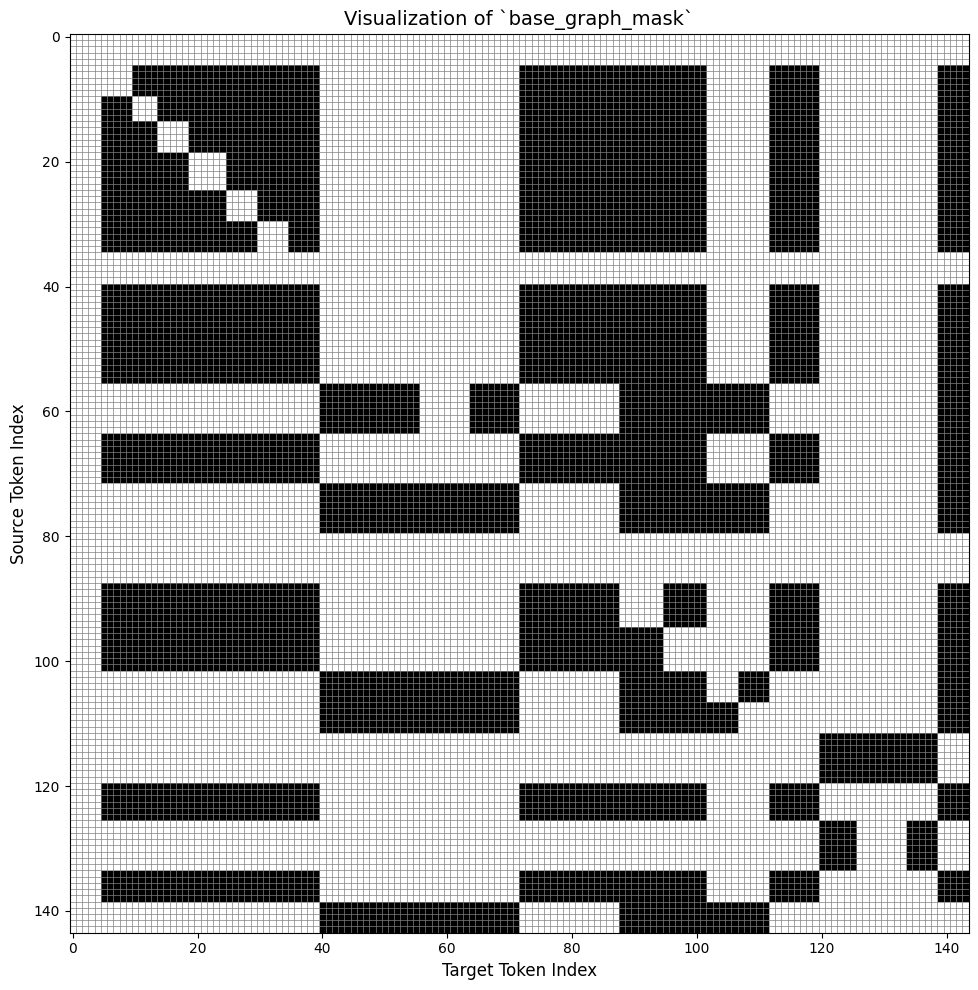

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization Code ---
fig, ax = plt.subplots(figsize=(10, 10))
# Use imshow with the 'binary' colormap (True=black, False=white)
cax = ax.imshow(base_graph_mask, cmap='binary', interpolation='none')

# Add gridlines to clearly separate the tokens
ax.set_xticks(np.arange(-.5, num_tool_tokens, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_tool_tokens, 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', size=0)

# Set labels and title
ax.set_xlabel("Target Token Index", fontsize=12)
ax.set_ylabel("Source Token Index", fontsize=12)
ax.set_title("Visualization of `base_graph_mask`", fontsize=14)

# Ensure the plot layout is tight and save the figure
plt.tight_layout()
# plt.savefig("base_graph_mask_visualization.png")

# print("Visualization saved to base_graph_mask_visualization.png")

In [77]:
tool_token_spans

{'Token Classification': (5, 10),
 'Translation': (10, 14),
 'Summarization': (14, 19),
 'Question Answering': (19, 25),
 'Conversational': (25, 30),
 'Text Generation': (30, 35),
 'Sentence Similarity': (35, 40),
 'Tabular Classification': (40, 46),
 'Object Detection': (46, 51),
 'Image Classification': (51, 56),
 'Image-to-Image': (56, 64),
 'Image-to-Text': (64, 72),
 'Text-to-Image': (72, 80),
 'Text-to-Video': (80, 88),
 'Visual Question Answering': (88, 95),
 'Document Question Answering': (95, 102),
 'Image Segmentation': (102, 107),
 'Depth Estimation': (107, 112),
 'Text-to-Speech': (112, 120),
 'Automatic Speech Recognition': (120, 126),
 'Audio-to-Audio': (126, 134),
 'Audio Classification': (134, 139),
 'Image Editing': (139, 144)}

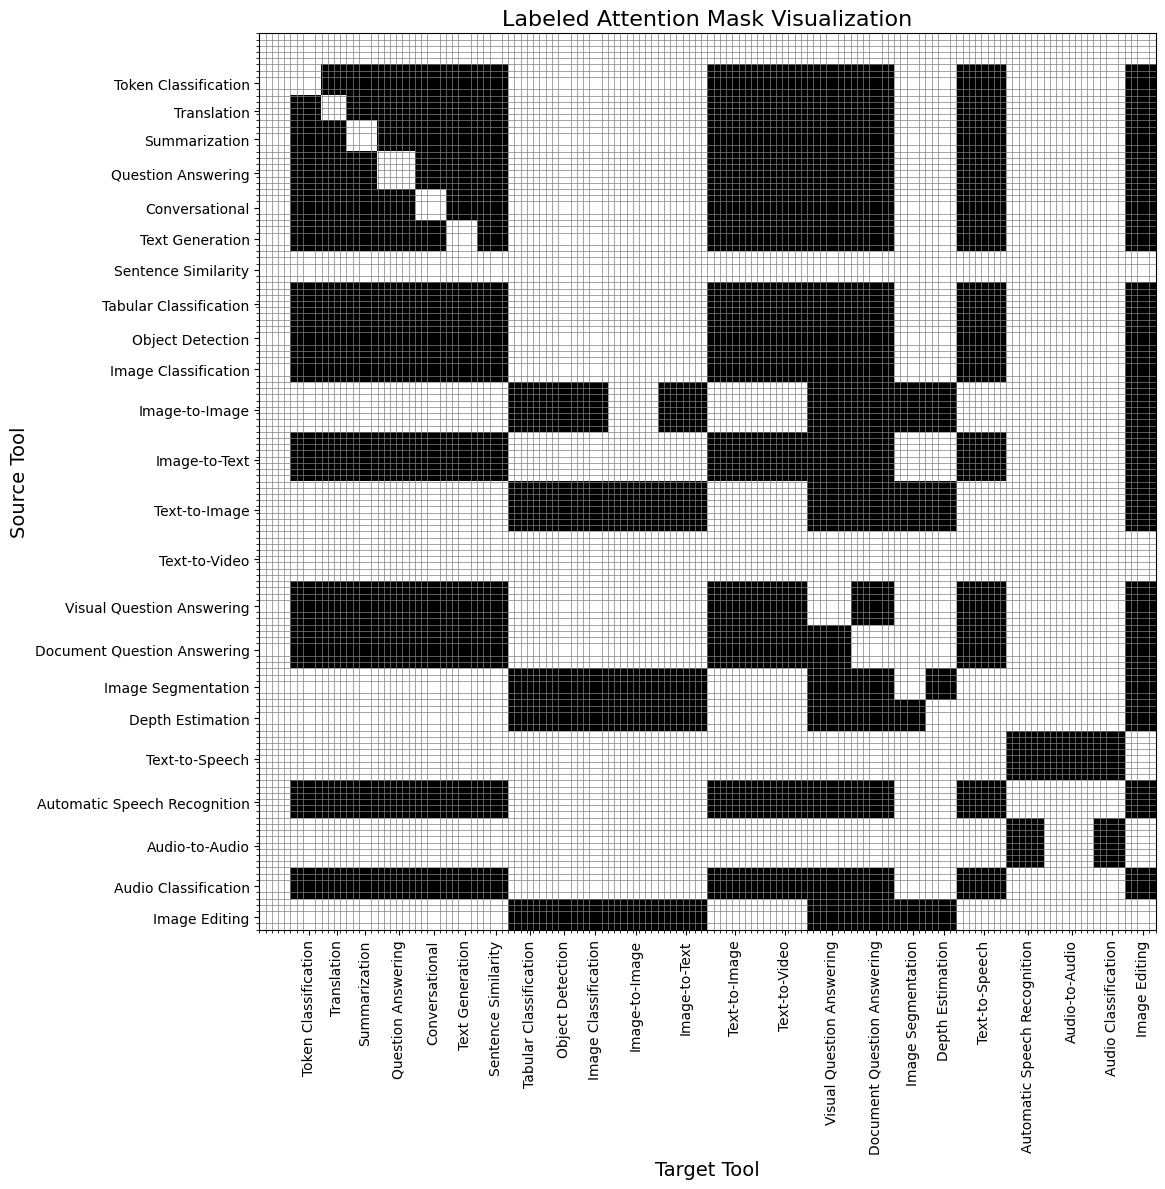

In [78]:

# 1. Prepare tick positions and labels from the spans dictionary
tick_positions = []
tick_labels = []
for tool_name, (start, end) in tool_token_spans.items():
    # Place the tick in the middle of the token span
    tick_positions.append((start + end) / 2)
    tick_labels.append(tool_name)

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(base_graph_mask, cmap='binary', interpolation='none')

# 3. Set the custom ticks and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha="center") # Rotate for readability

ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

# Minor gridlines can help delineate the actual token boundaries
ax.set_xticks(np.arange(-.5, num_tool_tokens, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_tool_tokens, 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

# 4. Set final labels and save the plot
ax.set_xlabel("Target Tool", fontsize=14)
ax.set_ylabel("Source Tool", fontsize=14)
ax.set_title("Labeled Attention Mask Visualization", fontsize=16)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# plt.savefig("labeled_mask_visualization.png")

# print("Labeled visualization saved to labeled_mask_visualization.png")

In [81]:
from transformers import Gemma3Processor

In [116]:
from transformers import Gemma3Processor
import torch

class GraphGemma3Processor(Gemma3Processor):
    def __init__(self, image_processor, tokenizer, *args, **kwargs):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer, *args, **kwargs)
        self.chat_template = self.tokenizer.chat_template
        self.graph_node_token = "[NODE]"
        self.tokenizer.add_special_tokens({"additional_special_tokens": [self.graph_node_token]})

    def __call__(
        self,
        text=None,
        images=None,
        graph_nodes=None, # <-- New argument for your graph nodes
        graph_links=None, # <-- New argument for your graph links
        padding=False,
        truncation=False,
        return_tensors="pt",
        **kwargs,
    ):
        # 1. Handle text and images using the original processor's logic
        processed_inputs = super().__call__(
            text=text,
            images=images,
            padding=padding,
            truncation=truncation,
            return_tensors=return_tensors,
            **kwargs,
        )

        # 2. If graph data is provided, process it and add it to the output
        if graph_nodes is not None and graph_links is not None:
            # This is where your custom logic from previous steps goes.
            # For simplicity, let's assume the graph is serialized after the text.
            
            # a. Serialize graph into a string
            graph_string = ""
            node_positions = {}
            current_pos = len(processed_inputs["input_ids"][0]) # Position after text
            
            for i, node in enumerate(graph_nodes):
                node_str = f" {self.graph_node_token} {node['id']}"
                graph_string += node_str
                # We need to track token positions for the attention mask
                # This is a simplified example; you'd use your more robust span tracking
                node_positions[node['id']] = current_pos 
                current_pos += len(self.tokenizer.encode(node_str, add_special_tokens=False))

            # b. Tokenize the graph string and combine with text tokens
            graph_tokens = self.tokenizer(graph_string, add_special_tokens=False, return_tensors=return_tensors)["input_ids"]
            processed_inputs["input_ids"] = torch.cat([processed_inputs["input_ids"], graph_tokens], dim=1)
            
            # c. Create and add token_type_ids
            # (0=text, 1=image, let's use 2=graph)
            text_image_len = processed_inputs["token_type_ids"].shape[1]
            graph_len = graph_tokens.shape[1]
            graph_type_ids = torch.full((1, graph_len), 2) # Assign '2' for graph
            
            processed_inputs["token_type_ids"] = torch.cat(
                [processed_inputs["token_type_ids"], graph_type_ids], dim=1
            )
            
            # d. Create the graph-specific attention mask (your base_graph_mask)
            # This would be combined with the main attention mask inside the model
            seq_len = processed_inputs["input_ids"].shape[1]
            graph_attention_mask = torch.zeros((seq_len, seq_len), dtype=torch.bool)
            
            for link in graph_links:
                source_idx = node_positions.get(link['source'])
                target_idx = node_positions.get(link['target'])
                if source_idx is not None and target_idx is not None:
                    # In a real scenario, you'd use your token spans here
                    graph_attention_mask[source_idx, target_idx] = True
            
            processed_inputs["graph_attention_mask"] = graph_attention_mask.unsqueeze(0) # Add batch dim

            # e. Update the main attention mask to include the new tokens
            processed_inputs["attention_mask"] = torch.cat(
                [processed_inputs["attention_mask"], torch.ones_like(graph_tokens)], dim=1
            )

        return processed_inputs

In [117]:
from PIL import Image
from transformers import AutoProcessor

original_processor = AutoProcessor.from_pretrained("google/gemma-3-4b-it")


# 2. Extract the individual components from the loaded object
image_processor = original_processor.image_processor
tokenizer = original_processor.tokenizer
processor = GraphGemma3Processor(image_processor, tokenizer)

image_path = "./pikachu.png"
image = Image.open(image_path).convert("RGB")

# 2. Define your graph data
nodes = [{"id": "t1", "name": "Summarize"}, {"id": "t2", "name": "Translate"}]
links = [{"source": "t1", "target": "t2"}]
text_prompt = "Based on the tools, process this document."

# 3. Call the processor with all data types



In [118]:
final_inputs = processor(text=text_prompt, graph_nodes=nodes, graph_links=links)

In [119]:
final_inputs

{'input_ids': tensor([[     2,  22515,    580,    506,   6436, 236764,   1657,    672,   2354,
         236761, 236743, 262145,    494, 236770, 236743, 262145,    494, 236778]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2]]), 'graph_attention_mask': tensor([[[False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False],
         [False, False, False, False, Fal

In [107]:
final_inputs.graph_attention_mask.shape

torch.Size([1, 17, 17])

In [108]:
processor

GraphGemma3Processor:
- image_processor: Gemma3ImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_pan_and_scan": null,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "Gemma3ImageProcessor",
  "image_seq_length": 256,
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "pan_and_scan_max_num_crops": null,
  "pan_and_scan_min_crop_size": null,
  "pan_and_scan_min_ratio_to_activate": null,
  "processor_class": "Gemma3Processor",
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 896,
    "width": 896
  }
}

- tokenizer: GemmaTokenizerFast(name_or_path='google/gemma-3-4b-it', vocab_size=262144, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'additional_special_tokens': ['[NODE]'], 'boi_token': '<start_of_

In [121]:
# Your conversational history
message = [
    {"role": "user", "content": "Here is a graph of tools. Please tell me how to get from Summarization to Text2Image."}
]

# Your structured graph data
graph_data = {
    "nodes": [{"id": "Summarization"}, {"id": "Translation"}, {"id": "Text2Image"}],
    "links": [{"source": "Summarization", "target": "Translation"}, {"source": "Translation", "target": "Text2GImage"}]
}

chat_template = processor.apply_chat_template(message, add_generation_prompt=True, tokenize=False)

print(chat_template)



final_inputs = processor(
    text=chat_template,
    graph_nodes=graph_data["nodes"],
    graph_links=graph_data["links"],
    return_tensors="pt"
)

print(final_inputs)

<bos><start_of_turn>user
Here is a graph of tools. Please tell me how to get from Summarization to Text2Image.<end_of_turn>
<start_of_turn>model

{'input_ids': tensor([[     2,      2,    105,   2364,    107,   8291,    563,    496,   3753,
            529,   6436, 236761,   7323,   3442,    786,   1217,    531,    974,
            699, 119281,   1854,    531,   5590, 236778,   1779, 236761,    106,
            107,    105,   4368,    107, 236743, 262145, 119281,   1854, 236743,
         262145,  52338, 236743, 262145,   5590, 236778,   1779]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]), 'graph_attention_mask': tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False

In [122]:
final_inputs


{'input_ids': tensor([[     2,      2,    105,   2364,    107,   8291,    563,    496,   3753,
            529,   6436, 236761,   7323,   3442,    786,   1217,    531,    974,
            699, 119281,   1854,    531,   5590, 236778,   1779, 236761,    106,
            107,    105,   4368,    107, 236743, 262145, 119281,   1854, 236743,
         262145,  52338, 236743, 262145,   5590, 236778,   1779]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]), 'graph_attention_mask': tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False,

In [130]:
final_inputs.input_ids.tolist()

[[2,
  2,
  105,
  2364,
  107,
  8291,
  563,
  496,
  3753,
  529,
  6436,
  236761,
  7323,
  3442,
  786,
  1217,
  531,
  974,
  699,
  119281,
  1854,
  531,
  5590,
  236778,
  1779,
  236761,
  106,
  107,
  105,
  4368,
  107,
  236743,
  262145,
  119281,
  1854,
  236743,
  262145,
  52338,
  236743,
  262145,
  5590,
  236778,
  1779]]

In [132]:
processor.decode(final_inputs.input_ids.tolist()[0])

'<bos><bos><start_of_turn>user\nHere is a graph of tools. Please tell me how to get from Summarization to Text2Image.<end_of_turn>\n<start_of_turn>model\n [NODE] Summarization [NODE] Translation [NODE] Text2Image'

In [137]:
from transformers import Gemma3Processor
import torch

class GraphGemma3Processor(Gemma3Processor):
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        self.chat_template = self.tokenizer.chat_template
        # Add special tokens if you haven't already
        self.graph_node_token = "[NODE]"
        self.tokenizer.add_special_tokens({"additional_special_tokens": [self.graph_node_token]})

    def __call__(self, conversation, add_generation_prompt=True, **kwargs):
        # 1. Serialize the structured conversation into a single string
        prompt_string = ""
        for message in conversation:
            role = message["role"]
            # Start the turn for the role
            prompt_string += f"<start_of_turn>{role}\n"
            
            # Process the content, which can be a list
            for part in message["content"]:
                if part["type"] == "text":
                    prompt_string += part["text"]
                elif part["type"] == "graph":
                    # Serialize the graph nodes into the prompt
                    graph_str = ""
                    for node in part["nodes"]:
                        graph_str += f" {self.graph_node_token} {node['id']}"
                    prompt_string += graph_str

            prompt_string += "<end_of_turn>\n"

        # 2. Add the generation prompt for the model's turn
        if add_generation_prompt:
            prompt_string += "<start_of_turn>model\n"

        # 3. Tokenize the final, correctly formatted string
        # The tokenizer handles the rest.
        return self.tokenizer(prompt_string, **kwargs)

# --- Example Usage ---

# Assume 'original_processor' is loaded
# image_processor = original_processor.image_processor
# tokenizer = original_processor.tokenizer
# processor = GraphGemma3Processor(image_processor, tokenizer)

# Your structured conversation data
conversation_data = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Based on this graph, how do I get from Summarization to Text2Image?"},
            {"type": "graph", "nodes": [{"id": "Summarization"}, {"id": "Translation"}, {"id": "Text2Image"}], "links": [{"source": "Summarization", "target": "Translation"}, {"source": "Translation", "target": "Text2GImage"}]}
        ]
    }
]

# A single call now does everything correctly


In [136]:
final_inputs = processor(conversation=conversation_data, return_tensors="pt")

decoded_text = processor.decode(final_inputs.input_ids[0])
print(decoded_text)

ValueError: Provide at least one of `text` or `images`.

In [139]:
import torch
from transformers import AutoProcessor, Gemma3Processor

class GraphGemma3Processor(Gemma3Processor):
    """
    The definitive custom processor. It takes a structured conversation
    (including text and graph data), serializes it into a single, correctly
    ordered prompt, and then creates all necessary tensors.
    """
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        self.chat_template = self.tokenizer.chat_template
        self.graph_node_token = "[NODE]"
        # Important: resize model embeddings if you add new tokens
        self.tokenizer.add_special_tokens({"additional_special_tokens": [self.graph_node_token]})

    def __call__(self, conversation, add_generation_prompt=True, return_tensors="pt", **kwargs):
        
        prompt_string = ""
        graph_parts = [] # To store graph info for later processing

        # --- Step 1: Serialize the conversation into a single string ---
        # The graph data is embedded directly into the user's turn.
        for message in conversation:
            role = message["role"]
            prompt_string += f"<start_of_turn>{role}\n"
            
            for part in message["content"]:
                if part["type"] == "text":
                    prompt_string += part["text"]
                elif part["type"] == "graph":
                    # Temporarily store graph data and serialize nodes into the string
                    graph_parts.append(part)
                    for node in part["nodes"]:
                        prompt_string += f" {self.graph_node_token} {node['id']}"
            
            prompt_string += "<end_of_turn>\n"

        if add_generation_prompt:
            prompt_string += "<start_of_turn>model\n"

        # --- Step 2: Tokenize the final, complete prompt string ---
        processed_inputs = self.tokenizer(prompt_string, return_tensors=return_tensors, **kwargs)

        # --- Step 3: Create custom tensors based on the tokenized output ---
        # Now that we have the final tokens, we can build the graph masks.
        if graph_parts:
            # Re-tokenize node strings to find their token lengths and calculate spans
            tool_token_spans = {}
            # Find the start of the first graph node
            # This is a robust way to find where the graph part begins
            text_part_str = ""
            for part in conversation[0]["content"]: # Assuming graph is in first message
                 if part["type"] == "text":
                    text_part_str += part["text"]
            
            # Length of all text before the graph begins
            # +3 for bos, sot_user, and newline
            current_pos = len(self.tokenizer.encode(f"<bos><start_of_turn>user\n{text_part_str}")) - 1

            for node in graph_parts[0]["nodes"]: # Assuming one graph block
                node_str = f" {self.graph_node_token} {node['id']}"
                node_tokens = self.tokenizer.encode(node_str, add_special_tokens=False)
                
                start_idx = current_pos
                end_idx = start_idx + len(node_tokens)
                tool_token_spans[node['id']] = (start_idx, end_idx)
                current_pos = end_idx

            # a. Create the graph attention mask
            seq_len = processed_inputs["input_ids"].shape[1]
            graph_attention_mask = torch.zeros((seq_len, seq_len), dtype=torch.bool)
            for link in graph_parts[0]["links"]:
                source_id, target_id = link["source"], link["target"]
                if source_id in tool_token_spans and target_id in tool_token_spans:
                    source_start, source_end = tool_token_spans[source_id]
                    target_start, target_end = tool_token_spans[target_id]
                    graph_attention_mask[source_start:source_end, target_start:target_end] = True
            
            processed_inputs["graph_attention_mask"] = graph_attention_mask.unsqueeze(0)

            # b. Create token_type_ids (0 for text, 2 for graph)
            token_type_ids = torch.zeros(seq_len, dtype=torch.long)
            for start, end in tool_token_spans.values():
                token_type_ids[start:end] = 2
            processed_inputs["token_type_ids"] = token_type_ids.unsqueeze(0)

        return processed_inputs

# --------------------------------------------------------------------------
# EXAMPLE USAGE
# --------------------------------------------------------------------------
if __name__ == "__main__":
    model_id = "google/gemma-3-4b-it"
    original_processor = AutoProcessor.from_pretrained(model_id)
    
    processor = GraphGemma3Processor(
        image_processor=original_processor.image_processor,
        tokenizer=original_processor.tokenizer
    )
    # Important: The model's embedding matrix must be resized to account for the new special token
    # model.resize_token_embeddings(len(processor.tokenizer))

    # --- Sample Data (structured correctly) ---
    conversation_data = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Based on this graph, how do I get from Summarization to Text2Image?"},
                {"type": "graph", 
                 "nodes": [{"id": "Summarization"}, {"id": "Translation"}, {"id": "Text2Image"}], 
                 "links": [{"source": "Summarization", "target": "Translation"}, {"source": "Translation", "target": "Text2Image"}]
                }
            ]
        }
    ]

    # --- A single, correct processing call ---
    final_inputs = processor(conversation=conversation_data, return_tensors="pt")

    # --- Verification ---
    print("✅ Processing complete. Verifying outputs:\n")

    print("--- 1. Decoded Input (Correct Structure) ---")
    decoded_text = processor.decode(final_inputs["input_ids"][0])
    print(decoded_text)
    
    print("\n--- 2. Token Type IDs ---")
    print(final_inputs["token_type_ids"])

    print("\n--- 3. Graph Attention Mask Shape ---")
    print(f"Shape: {final_inputs['graph_attention_mask'].shape}")

✅ Processing complete. Verifying outputs:

--- 1. Decoded Input (Correct Structure) ---
<bos><start_of_turn>user
Based on this graph, how do I get from Summarization to Text2Image? [NODE] Summarization [NODE] Translation [NODE] Text2Image<end_of_turn>
<start_of_turn>model


--- 2. Token Type IDs ---
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0]])

--- 3. Graph Attention Mask Shape ---
Shape: torch.Size([1, 38, 38])


In [143]:
final_inputs['input_ids']

tensor([[     2,    105,   2364,    107,  22515,    580,    672,   3753, 236764,
           1217,    776,    564,    974,    699, 119281,   1854,    531,   5590,
         236778,   1779, 236881, 236743, 262145, 119281,   1854, 236743, 262145,
          52338, 236743, 262145,   5590, 236778,   1779,    106,    107,    105,
           4368,    107]])

In [1]:
import torch
from transformers import AutoProcessor, Gemma3Processor

# --------------------------------------------------------------------------
# 1. DEFINE THE DYNAMIC, GRAPH-AWARE JINJA2 CHAT TEMPLATE
# --------------------------------------------------------------------------
# This template uses the tokenizer's special token variables (e.g., bos_token)
# and is designed to loop through a structured 'content' list that can
# contain parts of different types ('text', 'graph').

# CUSTOM_CHAT_TEMPLATE_FOR_GRAPH = """
# {% for message in messages %}
#     {{ bos_token }}
#     {% if message['role'] == 'user' %}
#         {{ '<start_of_turn>user\n' }}
#         {% if message['content'] is string %}
#             {# Handles simple text content #}
#             {{ message['content'] }}
#         {% else %}
#             {# Handles a list of content parts (e.g., text and graph) #}
#             {% for part in message['content'] %}
#                 {% if part['type'] == 'text' %}
#                     {{ part['text'] }}
#                 {% elif part['type'] == 'graph' %}
#                     {# Serializes graph nodes into the prompt #}
#                     {% for node in part['nodes'] %}
#                         {{ ' [NODE] ' + node['id'] }}
#                     {% endfor %}
#                 {% endif %}
#             {% endfor %}
#         {% endif %}
#         {{ '<end_of_turn>\n' }}
#     {% elif message['role'] == 'assistant' %}
#         {{ '<start_of_turn>model\n' + message['content'] + '<end_of_turn>\n' }}
#     {% endif %}
# {% endfor %}
# {% if add_generation_prompt %}
#     {{ '<start_of_turn>model\n' }}
# {% endif %}
# """


# This updated Jinja2 template uses whitespace control ('-')
# to produce a clean, single-line output without extra spaces.
CUSTOM_CHAT_TEMPLATE_FOR_GRAPH = """
{%- for message in messages -%}
    {{ bos_token }}
    {%- if message['role'] == 'user' -%}
        {{ '<start_of_turn>user\n' }}
        {%- if message['content'] is string -%}
            {{ message['content'] }}
        {%- else -%}
            {%- for part in message['content'] -%}
                {%- if part['type'] == 'text' -%}
                    {{ part['text'] }}
                {%- elif part['type'] == 'graph' -%}
                    {%- for node in part['nodes'] -%}
                        {{ ' [NODE] ' + node['id'] }}
                    {%- endfor -%}
                {%- endif -%}
            {%- endfor -%}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
    {%- elif message['role'] == 'assistant' -%}
        {{ '<start_of_turn>model\n' + message['content'] + '<end_of_turn>\n' }}
    {%- endif -%}
{%- endfor -%}
{%- if add_generation_prompt -%}
    {{ '<start_of_turn>model\n' }}
{%- endif -%}
"""



# --------------------------------------------------------------------------
# 2. DEFINE THE CUSTOM PROCESSOR
# --------------------------------------------------------------------------
class GraphGemma3Processor(Gemma3Processor):
    """
    A custom processor that overrides `apply_chat_template` to enable
    the model to understand structured graph data embedded within a conversation.
    """
    def __init__(self, image_processor, tokenizer):
        super().__init__(image_processor=image_processor, tokenizer=tokenizer)
        # Add the special token for graph nodes to the tokenizer
        # This is crucial for the model to learn a distinct embedding for it.
        self.tokenizer.add_special_tokens({"additional_special_tokens": ["[NODE]"]})
    
    def apply_chat_template(self, conversation, chat_template=None, **kwargs):
        """
        Overrides the base method. If no template is specified by the user,
        it defaults to our custom, graph-aware Jinja2 template.
        """
        # If the user doesn't provide a specific template, use our new one.
        if chat_template is None:
            chat_template = CUSTOM_CHAT_TEMPLATE_FOR_GRAPH

        # Call the original tokenizer's method, which will use OUR template
        # to perform the formatting and tokenization.
        return self.tokenizer.apply_chat_template(
            conversation,
            chat_template=chat_template,
            **kwargs
        )

# --------------------------------------------------------------------------
# 3. EXAMPLE USAGE AND VERIFICATION
# --------------------------------------------------------------------------
if __name__ == "__main__":
    # The ID of the model whose processor we want to extend
    model_id = "google/gemma-3-4b-it"
    print(f"Loading official processor for '{model_id}'...")

    # Load the official processor to get its pre-configured components
    try:
        original_processor = AutoProcessor.from_pretrained(model_id)
    except Exception as e:
        print(f"Could not load processor. Please ensure you have internet access and are logged into Hugging Face if required.")
        print(f"Error: {e}")
        exit()

    # Instantiate your custom processor with the official components
    print("Instantiating custom GraphGemma3Processor...")
    processor = GraphGemma3Processor(
        image_processor=original_processor.image_processor,
        tokenizer=original_processor.tokenizer
    )
    print("Custom processor created successfully.\n")

    # --- Prepare Sample Data ---
    # This structured conversation includes both a text part and a graph part
    conversation_data = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Based on this graph, how do I get from Summarization to Text2Image?"},
                {"type": "graph", 
                 "nodes": [{"id": "Summarization"}, {"id": "Translation"}, {"id": "Text2Image"}], 
                 "links": [] # Links are included for structure but not used in this template
                }
            ]
        }
    ]

    print("--- Input Conversation Data ---")
    print(conversation_data)
    print("\n--- Applying Chat Template... ---")

    # --- Process the data using a single, clean call ---
    # The custom processor internally uses the correct template to handle the graph data.
    final_inputs = processor.apply_chat_template(
        conversation_data,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt"
    )

    # --- Verification ---
    print("\n✅ Processing complete. Verifying outputs:\n")
    print(f"Shape of final input_ids tensor: {final_inputs.shape}")

    print("\n--- Final Decoded Prompt (Correct Structure) ---")
    # Decode the tensor back into a string to see the final formatted prompt
    decoded_text = processor.decode(final_inputs[0])
    print(decoded_text)

/home/ktshim/anaconda3/envs/pool/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading official processor for 'google/gemma-3-4b-it'...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Instantiating custom GraphGemma3Processor...
Custom processor created successfully.

--- Input Conversation Data ---
[{'role': 'user', 'content': [{'type': 'text', 'text': 'Based on this graph, how do I get from Summarization to Text2Image?'}, {'type': 'graph', 'nodes': [{'id': 'Summarization'}, {'id': 'Translation'}, {'id': 'Text2Image'}], 'links': []}]}]

--- Applying Chat Template... ---

✅ Processing complete. Verifying outputs:

Shape of final input_ids tensor: torch.Size([1, 38])

--- Final Decoded Prompt (Correct Structure) ---
<bos><start_of_turn>user
Based on this graph, how do I get from Summarization to Text2Image? [NODE] Summarization [NODE] Translation [NODE] Text2Image<end_of_turn>
<start_of_turn>model



In [2]:
decoded_text

'<bos><start_of_turn>user\nBased on this graph, how do I get from Summarization to Text2Image? [NODE] Summarization [NODE] Translation [NODE] Text2Image<end_of_turn>\n<start_of_turn>model\n'

In [3]:
final_inputs

tensor([[     2,    105,   2364,    107,  22515,    580,    672,   3753, 236764,
           1217,    776,    564,    974,    699, 119281,   1854,    531,   5590,
         236778,   1779, 236881, 236743, 262145, 119281,   1854, 236743, 262145,
          52338, 236743, 262145,   5590, 236778,   1779,    106,    107,    105,
           4368,    107]])